# ❇️ 리스크 관리 분석

# 0️⃣ 데이터 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import copy
from datetime import datetime, timedelta
import random
import warnings
from tqdm import tqdm

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print('✅ Malgun Gothic 설정!')
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    print('✅ AppleGothic 설정!')
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    print('✅ NanumGothic 설정!')

plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)  # 전체 출력 O

df=pd.read_csv('merged_df_segment_Final.csv')

date_cols = ['order_purchase_timestamp', 'order_approved_at', 'shipping_limit_date',
             'order_delivered_customer_date', 'order_delivered_carrier_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    
display(df.head())
print(df.shape)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_revenue,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB


(112650, 39)


# 1️⃣ EDA 및 통계

In [ ]:
# EDA 색상 지정
COLOR = "#0c29d0"
ALPHA = 0.5

## 1) Spearman 상관관계 -> 리스크 지표 탐색

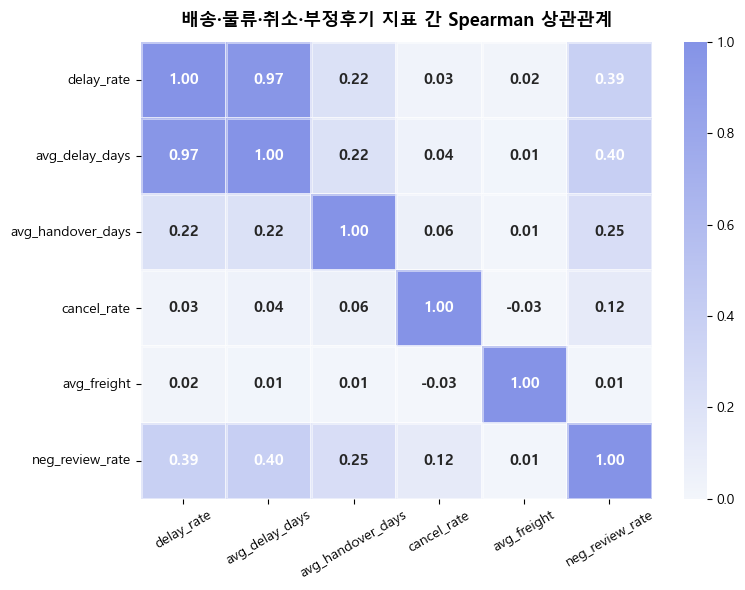

In [ ]:
df_eda = df.copy()

df_eda["handover_days"] = (
    df_eda["order_delivered_carrier_date"]
    - df_eda["order_approved_at"]
).dt.total_seconds() / (24 * 3600)

df_eda["order_month"] = df_eda["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# 배송지연일수 계산 (음수 → 0 처리)
df_eda["delivery_delay_days"] = (
    (df_eda["order_delivered_customer_date"] - df_eda["order_estimated_delivery_date"])
    .dt.days
).clip(lower=0)

# 배송 지연 여부
df_eda["is_delayed"] = (df_eda["delivery_delay_days"] > 0).astype(int)

# 취소 여부
df_eda["is_canceled"] = (df_eda["order_status"] == "canceled").astype(int)

# 부정 리뷰 여부
df_eda["is_negative_review"] = (df_eda["review_score"] <= 2).astype(int)

# 물류 전달 시간 (handover_days) 생성
df_eda["handover_days"] = (
    df_eda["order_delivered_carrier_date"]
    - df_eda["order_approved_at"]
).dt.total_seconds() / (24 * 3600)


# ================================
# Seller-Month 집계
# ================================
seller_month = (
    df_eda.groupby(["seller_id", "order_month"], as_index=False)
      .agg(
          orders=("order_id", "nunique"),
          delay_rate=("is_delayed", "mean"),
          avg_delay_days=("delivery_delay_days", "mean"),
          avg_handover_days=("handover_days", "mean"),
          cancel_rate=("is_canceled", "mean"),
          avg_freight=("freight_value", "mean"),
          neg_review_rate=("is_negative_review", "mean"),
      )
)
# 주문수 5건 이상
seller_month = seller_month[seller_month["orders"] >= 5].copy()
# 분석 대상 변수
corr_vars = [
    "delay_rate",
    "avg_delay_days",
    "avg_handover_days",
    "cancel_rate",
    "avg_freight",
    "neg_review_rate"
]
# Spearman 상관행렬
spearman_corr = seller_month[corr_vars].corr(method="spearman")
spearman_corr

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
# =========================
# Olist 컬러맵
# =========================
olist_cmap = LinearSegmentedColormap.from_list(
    "olist_blue",
    ["#E8EEF8", "#0C29D0"]  # 연한 블루 → Olist 블루
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap=olist_cmap,
    vmin=0, vmax=1,
    linewidths=0.8,
    linecolor="white",
    alpha=0.5,
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title(
    "배송·물류·취소·부정후기 지표 간 Spearman 상관관계",
    fontsize=13,
    weight="bold",
    pad=12
)
plt.xticks(fontsize=10, rotation=30)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 2) 리스크 지표 EDA

In [5]:
# ===============================
# 2. 부정리뷰 데이터만 필터링
# ===============================
negative_df = df_eda[df_eda["review_score"] <= 2].copy()
negative_df = df[df["review_score"] <= 2].copy()

print(f"전체 주문 수: {len(df):,}")

전체 주문 수: 112,650


In [6]:
segment_risk_summary = (
    negative_df
    .groupby("segment")
    .agg(
        orders=("order_id", "nunique"),
        delay_rate=("is_delayed", "mean"),
        cancel_rate=("is_canceled", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median")
    )
    .reset_index()
)

segment_risk_summary

,segment,orders,delay_rate,cancel_rate,avg_delay_days,median_delay_days
0,Enterprise,7564,0.279909,0.011386,-6.557775,-9.0
1,SMB,6596,0.271180,0.038856,-7.093299,-9.0


In [7]:
def plot_segment_bar(df, y_col, title, ylabel):
    plt.figure(figsize=(6, 4))
    
    sns.barplot(
        data=df,
        x="segment",
        y=y_col,
        color=COLOR,
        alpha=ALPHA
    )

    plt.title(title, fontsize=13)
    plt.xlabel("Segment")
    plt.ylabel(ylabel)

    # 값 라벨 표시
    for i, row in df.iterrows():
        val = row[y_col]
        if y_col.endswith("rate"):
            label = f"{val*100:.1f}%"
        else:
            label = f"{val:.2f}"
        plt.text(i, val, label, ha="center", va="bottom", fontsize=11)

    plt.tight_layout()
    plt.show()

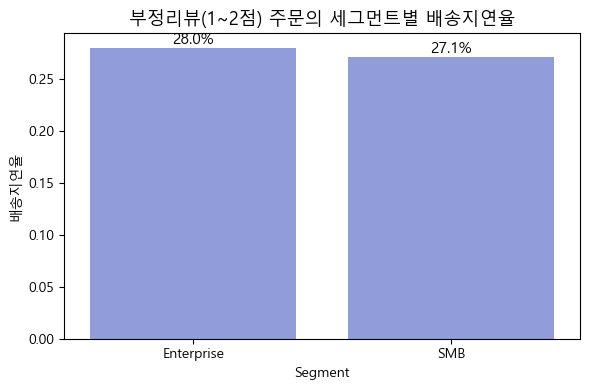

In [ ]:
# ==================================================
# 부정리뷰(1~2점) 주문의 세그먼트별 배송지연율 bar 차트
# ==================================================
plot_segment_bar(
    segment_risk_summary,
    y_col="delay_rate",
    title="부정리뷰(1~2점) 주문의 세그먼트별 배송지연율",
    ylabel="배송지연율"
)

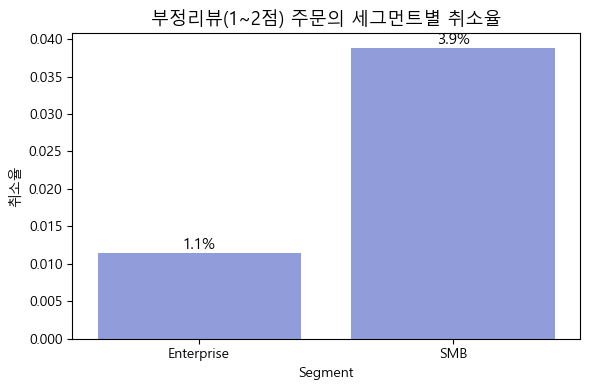

In [ ]:
# ==================================================
# 부정리뷰(1~2점) 주문의 세그먼트별 취소율 bar 차트
# ==================================================
plot_segment_bar(
    segment_risk_summary,
    y_col="cancel_rate",
    title="부정리뷰(1~2점) 주문의 세그먼트별 취소율",
    ylabel="취소율"
)

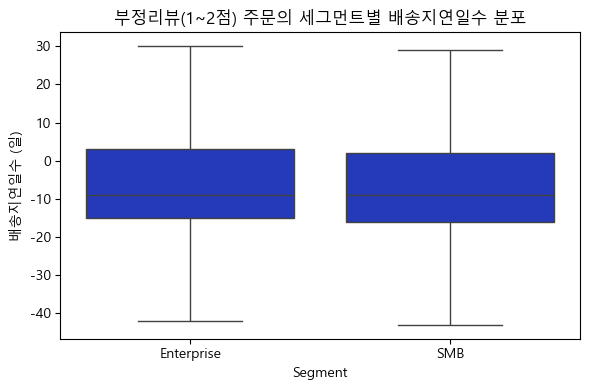

In [ ]:
# ==================================================
# 부정리뷰(1~2점) 주문의 세그먼트별 배송지연일수 박스플롯
# ==================================================
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=negative_df,
    x="segment",
    y="delivery_delay_days",
    color=COLOR,
    showfliers=False
)

plt.title("부정리뷰(1~2점) 주문의 세그먼트별 배송지연일수 분포")
plt.xlabel("Segment")
plt.ylabel("배송지연일수 (일)")
plt.tight_layout()
plt.show()

# 2️⃣ 카이제곱 검정

In [11]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'total_revenue',
       'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay_days', 'is_delayed', 'is_canceled',
       'product_category_name', 'product_category_name_english',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_city_clean', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'review_id', 'review_score',
       'review_comment_message', 'review_creation_date',
       'geolocation_zip_code_prefix', 'lat_mode', 'lng_mode',
       'geolocation_city', 'geolocation_state', 'seller_total_revenue',
       'segment'],
      dtype='object')

In [12]:
df["is_negative_review"] = (df["review_score"] <= 2).astype(int)

In [13]:
df_stat = df.copy()

In [14]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1) 교차표 생성
ct = pd.crosstab(df_stat["segment"], df_stat["is_negative_review"])

# 2) 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(ct)

# 3) 결과 출력
print("=== [카이제곱] 부정리뷰 여부 × 세그먼트 ===")
print(ct)
print("chi2:", chi2)
print("p-value:", p)
print("expected:")
print(expected)

=== [카이제곱] 부정리뷰 여부 × 세그먼트 ===
is_negative_review      0     1
segment                        
Enterprise          49273  9485
SMB                 45399  8493
chi2: 3.0488658653878957
p-value: 0.08079354421455388
expected:
[[49380.713502  9377.286498]
 [45291.286498  8600.713502]]


In [15]:
ct_delay = pd.crosstab(df_stat["segment"], df_stat["is_delayed"])
chi2, p, dof, expected = chi2_contingency(ct_delay)

print("\n=== [카이제곱] 배송지연 여부 × 세그먼트 ===")
print(ct_delay)
print("chi2:", chi2)
print("p-value:", p)
print("expected:")
print(expected)


=== [카이제곱] 배송지연 여부 × 세그먼트 ===
is_delayed    0.0   1.0
segment                
Enterprise  53797  4004
SMB         49134  3261
chi2: 21.962890982898237
p-value: 2.779734842666382e-06
expected:
[[53990.29666231  3810.70333769]
 [48940.70333769  3454.29666231]]


In [16]:
ct_cancel = pd.crosstab(df_stat["segment"], df_stat["is_canceled"])
chi2, p, dof, expected = chi2_contingency(ct_cancel)

print("\n=== [카이제곱] 취소 여부 × 세그먼트 ===")
print(ct_cancel)
print("chi2:", chi2)
print("p-value:", p)
print("expected:")
print(expected)


=== [카이제곱] 취소 여부 × 세그먼트 ===
is_canceled      0    1
segment                
Enterprise   58611  147
SMB          53497  395
chi2: 135.81840026686118
p-value: 2.186397298044203e-31
expected:
[[58475.29395473   282.70604527]
 [53632.70604527   259.29395473]]


In [17]:
import pandas as pd
from scipy.stats import chi2_contingency

def chi_square_with_interpretation(df, feature_col, segment_col="segment", positive_label=1):
    """
    feature_col: 이진 변수 컬럼명 (ex. 'is_negative_review', 'is_delayed', 'is_canceled')
    segment_col: 세그먼트 컬럼명 (기본: 'segment')
    positive_label: '1'로 볼 값 (기본: 1)
    """
    print("="*80)
    print(f"[카이제곱] {feature_col} × {segment_col}")
    print("="*80)
    
    # 1) 교차표
    ct = pd.crosstab(df[segment_col], df[feature_col])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    print("\n[교차표 (빈도)]")
    print(ct)
    print("\n[기대도수]")
    print(pd.DataFrame(expected, 
                       index=ct.index, 
                       columns=ct.columns))
    
    print(f"\nchi2 통계량: {chi2:.4f}")
    print(f"p-value   : {p:.6g}")
    print(f"자유도(df): {dof}")
    
    # 2) 세그먼트별 비율 계산
    rate = (
        df.groupby(segment_col)[feature_col]
          .mean()
          .rename("rate")
          .reset_index()
    )
    
    print("\n[세그먼트별 비율]")
    for _, row in rate.iterrows():
        seg = row[segment_col]
        r   = row["rate"]
        print(f"- {seg}: {r*100:.2f}%")
    
    # 3) 해석
    print("\n[해석]")
    if p < 0.05:
        print("→ p < 0.05 이므로, 세그먼트에 따라 해당 이벤트 발생 비율에 **유의한 차이**가 있습니다.")
        
        # 어떤 세그먼트가 더 높은지
        rate_sorted = rate.sort_values("rate", ascending=False)
        top_seg = rate_sorted.iloc[0][segment_col]
        top_val = rate_sorted.iloc[0]["rate"]
        bottom_seg = rate_sorted.iloc[-1][segment_col]
        bottom_val = rate_sorted.iloc[-1]["rate"]
        
        print(f"→ 특히, '{top_seg}' 세그먼트의 {feature_col} 비율이 가장 높습니다.")
        print(f"   - {top_seg}: {top_val*100:.2f}%")
        print(f"   - {bottom_seg}: {bottom_val*100:.2f}%")
        print(f"→ 즉, {top_seg} 셀러가 {bottom_seg}에 비해 상대적으로 더 위험한 상태라고 해석할 수 있습니다.")
    else:
        print("→ p ≥ 0.05 이므로, 세그먼트에 따라 해당 이벤트 발생 비율에 **유의한 차이가 없다**고 볼 수 있습니다.")

In [ ]:
# 부정 리뷰 비율 검정 결과
print(chi_square_with_interpretation(df_stat, "is_negative_review"))

[카이제곱] is_negative_review × segment

[교차표 (빈도)]
is_negative_review      0     1
segment                        
Enterprise          49273  9485
SMB                 45399  8493

[기대도수]
is_negative_review             0            1
segment                                      
Enterprise          49380.713502  9377.286498
SMB                 45291.286498  8600.713502

chi2 통계량: 3.0489
p-value   : 0.0807935
자유도(df): 1

[세그먼트별 비율]
- Enterprise: 16.14%
- SMB: 15.76%

[해석]
→ p ≥ 0.05 이므로, 세그먼트에 따라 해당 이벤트 발생 비율에 **유의한 차이가 없다**고 볼 수 있습니다.
None


In [ ]:
# 배송 지연 여부 검정 결과
print(chi_square_with_interpretation(df_stat, "is_delayed"))

[카이제곱] is_delayed × segment

[교차표 (빈도)]
is_delayed    0.0   1.0
segment                
Enterprise  53797  4004
SMB         49134  3261

[기대도수]
is_delayed           0.0          1.0
segment                              
Enterprise  53990.296662  3810.703338
SMB         48940.703338  3454.296662

chi2 통계량: 21.9629
p-value   : 2.77973e-06
자유도(df): 1

[세그먼트별 비율]
- Enterprise: 6.93%
- SMB: 6.22%

[해석]
→ p < 0.05 이므로, 세그먼트에 따라 해당 이벤트 발생 비율에 **유의한 차이**가 있습니다.
→ 특히, 'Enterprise' 세그먼트의 is_delayed 비율이 가장 높습니다.
   - Enterprise: 6.93%
   - SMB: 6.22%
→ 즉, Enterprise 셀러가 SMB에 비해 상대적으로 더 위험한 상태라고 해석할 수 있습니다.
None


In [ ]:
# 주문 취소 여부 검정 결과
print(chi_square_with_interpretation(df_stat, "is_canceled"))

[카이제곱] is_canceled × segment



[교차표 (빈도)]
is_canceled      0    1
segment                
Enterprise   58611  147
SMB          53497  395

[기대도수]
is_canceled             0           1
segment                              
Enterprise   58475.293955  282.706045
SMB          53632.706045  259.293955

chi2 통계량: 135.8184
p-value   : 2.1864e-31
자유도(df): 1

[세그먼트별 비율]
- Enterprise: 0.25%
- SMB: 0.73%

[해석]
→ p < 0.05 이므로, 세그먼트에 따라 해당 이벤트 발생 비율에 **유의한 차이**가 있습니다.
→ 특히, 'SMB' 세그먼트의 is_canceled 비율이 가장 높습니다.
   - SMB: 0.73%
   - Enterprise: 0.25%
→ 즉, SMB 셀러가 Enterprise에 비해 상대적으로 더 위험한 상태라고 해석할 수 있습니다.
None


# 3️⃣ BERT 감정분석

In [21]:
df_sentiment = df.copy()

# 1) 리뷰 번역 데이터 불러오기
reviews_translated = pd.read_csv('olist_order_reviews_dataset_translated.csv')
rt = reviews_translated[['review_id', 'order_id', 'review_score', 'review_comment_message', 'review_comment_translated']]

# 2) 병합
df_sentiment = pd.merge(df_sentiment, rt, how='left', on=['review_id', 'order_id', 'review_score', 'review_comment_message'])

## 1) BERT 점수로만 감정분석 수행

In [22]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings(action='ignore')

# 1. 중복 제거
df_sent = df_sentiment.drop_duplicates(subset=['seller_id', 'review_id', 'review_comment_translated'])

# 2. 리뷰 내용이 있는 데이터만 추출
df_clean = df_sent[df_sent['review_comment_translated'].notnull()].copy()

# 테스트
df_target_onlyBert = df_clean.head(50).copy() 
# df_target_onlyBert = df_clean.copy() # 전체 데이터 대상

print(f"분석 대상 리뷰 개수: {len(df_target_onlyBert)}개")

# 3. 감정분석 파이프라인 로드
# 1 star(매우 부정) ~ 5 stars(매우 긍정)
sentiment_analyzer = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)

# 4. 감정분석 함수 정의
def analyze_sentiment(text):
    try:
        # 텍스트가 너무 길면 BERT 모델 제한(512토큰)에 걸릴 수 있어 512자에서 자르기
        result = sentiment_analyzer(text[:510])[0]
        
        label_str = result['label'] # ex. '1 star', '5 stars'
        score = result['score']     # 확신도 (0~1)
        
        # 'n stars'에서 숫자만 추출 (int)
        star_rating = int(label_str.split()[0])
        
        # Label 매핑 (1-2: Negative, 3: Neutral, 4-5: Positive)
        if star_rating <= 2:
            final_label = 'negative'
        elif star_rating == 3:
            final_label = 'neutral'
        else: # 4, 5
            final_label = 'positive'
            
        return final_label, score, star_rating
        
    except Exception as e:
        return 'error', 0.0, 0

# 5. 데이터프레임에 적용
tqdm.pandas()
df_target_onlyBert[['sentiment_label', 'sentiment_score', 'pred_star']] = df_target_onlyBert['review_comment_translated'].progress_apply(
    lambda x: pd.Series(analyze_sentiment(x))
)

# 6. 결과 확인
print("\n--- 결과 샘플 ---")
print(df_target_onlyBert[['review_comment_translated', 'sentiment_label', 'sentiment_score']].head(20))

print("\n--- 감정 분포 ---")
print(df_target_onlyBert['sentiment_label'].value_counts())

c:\Users\ahb62\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


분석 대상 리뷰 개수: 50개


Device set to use cpu
100%|██████████| 50/50 [00:02<00:00, 16.77it/s]



--- 결과 샘플 ---
                            review_comment_translated sentiment_label  \
0         Perfect, product delivered before combined.        positive   
2   It arrived before the scheduled deadline and t...        positive   
4                 I liked it because it came on time.        positive   
8   In the description of the product when I went ...        negative   
10  The product box came with a small damage, but ...         neutral   
11  I was a little sad, I thought the heart color ...         neutral   
12                 Excellent online shopping service.        positive   
17  I change my opinion as soon as I receive the p...        negative   
18           I received td right before the deadline!        negative   
19                                       Good product        positive   
20                                                  5        positive   
23                                    super recommend        positive   
25  I received Long 10 days after pu

In [23]:
# df_target_onlyBert[['review_id','review_score', 'review_comment_translated', 'sentiment_label', 'sentiment_score']].to_csv('sentiment_test_onlyBERT.csv')

## 2) 실제 리뷰 점수와 BERT 점수 가중치 줘서 `hybrid_score`로 감정 분석

### 샘플 500개 분석 수행

In [ ]:
from transformers import pipeline

df_target_sample = df_clean.head(500).copy() # 테스트용

# ==============================================
# 1. 감정분석 파이프라인 로드
# ==============================================
sentiment_analyzer = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)

def get_bert_star(text):
    '''BERT 점수 가져오는 함수'''
    try:
        result = sentiment_analyzer(text[:510])[0]
        stars = int(result['label'].split()[0])
        return stars
    except:
        return 3 # 에러 시 중립 처리

# ==============================================
# 2. BERT 예측 점수 추출
# ==============================================
print("AI 분석 진행 중...")
tqdm.pandas()
df_target_sample['bert_star'] = df_target_sample['review_comment_translated'].apply(get_bert_star)

# ==============================================
# 3. 하이브리드 점수 계산 (가중치 적용) 
# -> (0.8, 0.2) & (0.7, 0.3) 수행
# ==============================================
# w_real = 0.7
# w_ai = 0.3
w_real = 0.8
w_ai = 0.2

df_target_sample['hybrid_score'] = (df_target_sample['review_score'] * w_real) + (df_target_sample['bert_star'] * w_ai)

# ==============================================
# 4. 최종 라벨링 함수 (Hybrid Score 기준)
# ==============================================
def assign_final_label(score):
    # 점수 범위: 1 ~ 5
    if score >= 3.4:     # 3.4 이상이면 긍정
        return 'positive'
    elif score <= 2.8:   # 2.8 이하이면 부정
        return 'negative'
    else:
        return 'neutral' # 2.8 ~ 3.5면 중립

df_target_sample['final_label'] = df_target_sample['hybrid_score'].apply(assign_final_label)

# ==============================================
# 5. 결과 비교 확인
# ==============================================
check_cols = ['review_comment_translated', 'review_score', 'bert_star', 'hybrid_score', 'final_label']

# 고객점수는 3점 이하 AI가 4점 이상으로 예측했던 케이스들 확인
mismatch = df_target_sample[(df_target_sample['review_score'] <= 3) & (df_target_sample['bert_star'] >= 4)]

print("\n--- 보정된 결과 (고객 3점 이하 vs AI 긍정 예측 케이스) ---")
display(mismatch[check_cols].head(10))

Device set to use cpu


AI 분석 진행 중...

--- 보정된 결과 (고객 3점 이하 vs AI 긍정 예측 케이스) ---


,review_comment_translated,review_score,bert_star,hybrid_score,final_label
19,Good product,3.0,4,3.3,neutral
20,5,3.0,5,3.6,positive
135,bom,3.0,5,3.6,positive
194,I ordered HD 500 GB SATA Notebook Samsung R520...,2.0,5,2.9,neutral
259,Quality product.,3.0,5,3.6,positive
266,The black edge paint is releasing in our good ...,2.0,4,2.6,negative
300,Generic cartridge being sold as original.,1.0,5,2.2,negative
321,"I bought some wicker baskets, bought 6, but a ...",3.0,4,3.3,neutral
399,"Good service, easy to buy delivery quickly.",3.0,4,3.3,neutral
501,Better than expected product.,1.0,5,2.2,negative


In [25]:
# 파일 저장
# df_target_sample.to_csv('df_sentiment_hybrid_500(0.7).csv')
# df_target_sample.to_csv('df_sentiment_hybrid_500(0.8).csv')

### 전체 대상 분석 수행

In [26]:
from transformers import pipeline

df_target = df_clean.copy()

# ==============================================
# 1. 감정분석 파이프라인 로드
# ==============================================
sentiment_analyzer = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)

def get_bert_star(text):
    '''BERT 점수 가져오는 함수'''
    try:
        result = sentiment_analyzer(text[:510])[0]
        stars = int(result['label'].split()[0])
        return stars
    except:
        return 3 # 에러 시 중립 처리

# ==============================================
# 2. BERT 예측 점수 추출
# ==============================================
print("AI 분석 진행 중...")
tqdm.pandas()
df_target['bert_star'] = df_target['review_comment_translated'].progress_apply(get_bert_star)

# ==============================================
# 3. 하이브리드 점수 계산 (가중치 적용)
# ==============================================
# review_score(고객 점수)에 80%, bert_star(AI 점수)에 20% 가중치 부여
w_real = 0.8
w_ai = 0.2

df_target['hybrid_score'] = (df_target['review_score'] * w_real) + (df_target['bert_star'] * w_ai)

# ==============================================
# 4. 최종 라벨링 함수 (Hybrid Score 기준)
# ==============================================
def assign_final_label(score):
    # 점수 범위: 1 ~ 5
    if score >= 3.4:     # 3.4 이상이면 긍정
        return 'positive'
    elif score <= 2.8:   # 2.8 이하이면 부정
        return 'negative'
    else:
        return 'neutral' # 2.8 ~ 3.5면 중립

df_target['final_label'] = df_target['hybrid_score'].apply(assign_final_label)

# ==============================================
# 5. 결과 비교 확인
# ==============================================
check_cols = ['review_comment_translated', 'review_score', 'bert_star', 'hybrid_score', 'final_label']

# 고객점수는 3점 이하 AI가 4점 이상으로 예측했던 케이스들 확인
mismatch = df_target[(df_target['review_score'] <= 3) & (df_target['bert_star'] >= 4)]

print("\n--- 보정된 결과 (고객 3점 이하 vs AI 긍정 예측 케이스) ---")
display(mismatch[check_cols].head(10))

Device set to use cpu


AI 분석 진행 중...


100%|██████████| 40912/40912 [21:10<00:00, 32.20it/s] 


--- 보정된 결과 (고객 3점 이하 vs AI 긍정 예측 케이스) ---


,review_comment_translated,review_score,bert_star,hybrid_score,final_label
19,Good product,3.0,4,3.2,neutral
20,5,3.0,5,3.4,positive
135,bom,3.0,5,3.4,positive
194,I ordered HD 500 GB SATA Notebook Samsung R520...,2.0,5,2.6,negative
259,Quality product.,3.0,5,3.4,positive
266,The black edge paint is releasing in our good ...,2.0,4,2.4,negative
300,Generic cartridge being sold as original.,1.0,5,1.8,negative
321,"I bought some wicker baskets, bought 6, but a ...",3.0,4,3.2,neutral
399,"Good service, easy to buy delivery quickly.",3.0,4,3.2,neutral
501,Better than expected product.,1.0,5,1.8,negative


In [ ]:
# 저장
df_target[['review_id', 'review_comment_translated', 'review_score', 'bert_star', 'hybrid_score', 'final_label']].to_csv('sentiment_target_final.csv')

# 3️⃣ 이동평균 (MA)

In [ ]:
# ==============================================
# 1. 데이터 전처리 및 정렬
# ==============================================
df_analysis = df.copy()

# 1) 부정 리뷰 정의
df_analysis['is_negative'] = df_analysis['review_score'].apply(lambda x: 1 if x <= 2 else 0)

# 2) 중복 제거
df_analysis = df_analysis.drop_duplicates(subset=['seller_id', 'review_id'])

# 3) 시간 순서 정렬
sort_col = 'order_purchase_timestamp'
df_analysis[sort_col] = pd.to_datetime(df_analysis[sort_col])
df_analysis = df_analysis.sort_values(by=['seller_id', sort_col])

# ==============================================
# 2. 리뷰 수 기준 필터링 (20건 이상)
# ==============================================
MIN_TOTAL_REVIEWS = 20

seller_counts = df_analysis.groupby('seller_id')['review_id'].nunique()
qualified_sellers = seller_counts[seller_counts >= MIN_TOTAL_REVIEWS].index
df_analysis = df_analysis[df_analysis['seller_id'].isin(qualified_sellers)]
filtered_seller_count = df_analysis['seller_id'].nunique()

print(f"\n[필터링 결과] 총 리뷰 {MIN_TOTAL_REVIEWS}개 이상인 셀러만 분석합니다.")
print(f" - 분석 대상: {filtered_seller_count}명")

# ==============================================
# 3. 이동평균 및 오염방지 동적 임계값
# ==============================================
WINDOW_SIZE = 10        
CHECK_RANGE = 10        
SIGMA_MULTIPLIER = 1.  
MIN_TOLERANCE = 0.30    
MAX_CAP = 0.50          

# 1) 현재 시점 이동평균 (Current MA)
df_analysis['current_ma'] = df_analysis.groupby('seller_id')['is_negative'].transform(lambda x: x.rolling(window=WINDOW_SIZE, min_periods=5).mean())

# -----------------------------------------------------------------
# 리스크 발생 시, 해당 데이터를 통계(평균, 표준편차) 갱신에서 제외하는 함수
# -----------------------------------------------------------------
def calculate_clean_threshold(group):
    '''리스크 발생 시, 해당 데이터를 통계(평균, 표준편차) 갱신에서 제외하는 함수'''
    thresholds = []
    triggers = []
    
    # 초기 변수 초기화
    n = 0
    sum_x = 0.0
    sum_sq = 0.0
    
    # 순차적으로 행을 훑으면서 계산
    for idx, row in group.iterrows():
        val = row['is_negative']
        ma = row['current_ma']
        
        # 1. 현재 시점의 통계 계산
        if n < 2:
            # 데이터가 너무 적을 땐 초기값 설정 (0으로 가정)
            mean = 0.0
            std = 0.0
        else:
            mean = sum_x / n
            variance = (sum_sq / n) - (mean ** 2) # 분산 = 제곱의 평균 - 평균의 제곱
            std = np.sqrt(max(variance, 0)) # 부동소수점 오차로 variance가 음수가 될 경우 방지
            
        # 2. 임계값 계산 (Max Cap 적용)
        calc_th = mean + (SIGMA_MULTIPLIER * std)
        final_th = min(max(calc_th, MIN_TOLERANCE), MAX_CAP)
        
        # 3. 리스크 판정
        is_risk = ma >= final_th
        
        # 결과 저장
        thresholds.append(final_th)
        triggers.append(is_risk)
        
        # 4. 리스크가 아닐 때만 통계에 반영
        if not is_risk:
            n += 1
            sum_x += val
            sum_sq += val ** 2 # 제곱의 평균 업데이트
            
    # Series로 반환
    return pd.DataFrame({
        'final_threshold': thresholds,
        'is_risk_triggered': triggers
    }, index=group.index)

# 그룹별로 함수 적용
print("⏳ 오염 방지 로직을 적용하여 임계값을 계산 중입니다...")
results = df_analysis.groupby('seller_id').apply(calculate_clean_threshold)

# MultiIndex 제거 및 원본 병합을 위해 레벨 정리
results = results.reset_index(level=0, drop=True)

df_analysis['final_threshold'] = results['final_threshold']
df_analysis['is_risk_triggered'] = results['is_risk_triggered']
print("✅ 계산 완료.")

# ==============================================
# 4. 리스크 셀러 추출
# ==============================================
recent_history = df_analysis.groupby('seller_id').tail(CHECK_RANGE)
risky_sellers_unpolluted_list = recent_history[recent_history['is_risk_triggered'] == True]['seller_id'].unique()

print(f"\n🚨 최근 위험 감지 셀러 수: {len(risky_sellers_unpolluted_list)}명")



[필터링 결과] 총 리뷰 20개 이상인 셀러만 분석합니다.
 - 분석 대상: 811명
⏳ 오염 방지 로직을 적용하여 임계값을 계산 중입니다...
✅ 계산 완료.

🚨 최근 위험 감지 셀러 수: 68명


In [ ]:
# ==============================================
# 시각화 부분만 따로 함수 정의
# ==============================================
def risk_analysis_unpolluted_plot(seller_id):
    '''시각화 부분만 따로 함수 정의'''
    target_seller = seller_id

    viz_data = df_analysis[df_analysis['seller_id'] == target_seller].reset_index(drop=True)
    total_reviews = viz_data['review_id'].nunique()

    plt.figure(figsize=(14, 6))

    # 1) 이동평균선
    plt.plot(viz_data.index, viz_data['current_ma'], color="#3615ec", linewidth=2, label=f'부정 리뷰 비율 (MA {WINDOW_SIZE})')

    # 2) 임계값 선
    plt.plot(viz_data.index, viz_data['final_threshold'], color='#2ecc71', linestyle='--', linewidth=2, label=f'동적 임계값')

    # 3) 리스크 지점 분리 표시
    triggers = viz_data[viz_data['is_risk_triggered']]

    if not triggers.empty:
    # 일반 리스크
        normal_risk = triggers[triggers['current_ma'] < 0.8]
        if not normal_risk.empty:
            plt.scatter(normal_risk.index, normal_risk['current_ma'], color='black', marker='x', s=80, linewidth=2, label='리스크 발생', zorder=5)
            
        # 심각한 리스크
        critical_risk = triggers[triggers['current_ma'] >= 0.8]
        if not critical_risk.empty:
            plt.scatter(critical_risk.index, critical_risk['current_ma'], color='red', marker='x', s=120, linewidth=3, label='심각한 리스크 (>= 80%)', zorder=6)

    # 최근 구간 배경색 표시
    last_idx = viz_data.index[-1]
    start_idx = max(0, last_idx - CHECK_RANGE)
    plt.axvspan(start_idx, last_idx, color='yellow', alpha=0.2, label=f'최근 검사 구간 ({CHECK_RANGE}건)')

    plt.title(f"리스크 분석 (이동평균) - 셀러 ID {target_seller}\n(리뷰 수: {total_reviews}건)")
    plt.xlabel("리뷰 순서")
    plt.ylabel("부정 리뷰 비율")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [32]:
print(risky_sellers_unpolluted_list)
print(len(risky_sellers_unpolluted_list))

['054694fa03fe82cec4b7551487331d74' '05f51e13da97139648b8125c31e5f51b'
 '17306570e772e7718c92a562d33f5f1d' '198c7ea11960a9844b544d9bcdca860c'
 '1ca7077d890b907f89be8c954a02686a' '1f9ab4708f3056ede07124aad39a2554'
 '23d7c96d4a1160db1c726b248601b25a' '25c5c91f63607446a97b143d2d535d31'
 '2d50d6282f8aa2257819a77bfaa0efe0' '2eb70248d66e0e3ef83659f71b244378'
 '3078096983cf766a32a06257648502d1' '33ac3e28642ab8bda860a2f693000e78'
 '37be5a7c751166fbc5f8ccba4119e043' '3fd1e727ba94cfe122d165e176ce7967'
 '4a3ccda38b2129705f3fb522db62ca31' '4c8b8048e33af2bf94f2eb547746a916'
 '4e06067cc08b3f41d837768d392c3ee3' '4e7c18b98d84e05cbae3ff0ff03846c2'
 '50c9975695009e5e6473912e83a6d1da' '52f0fe436a347ddad7ed5f9aa4e27eaa'
 '54965bbe3e4f07ae045b90b0b8541f52' '681fce914360217db47784ae28905a96'
 '688756f717c462a206ad854c5027a64a' '6fd52c528dcb38be2eea044946b811f8'
 '7008613ea464bad5cb9b83456e1e6a8f' '7aa4334be125fcdd2ba64b3180029f14'
 '7f152321c60a266edc53af1925ef96c1' '81f89e42267213cb94da7ddc301651da'
 '8221

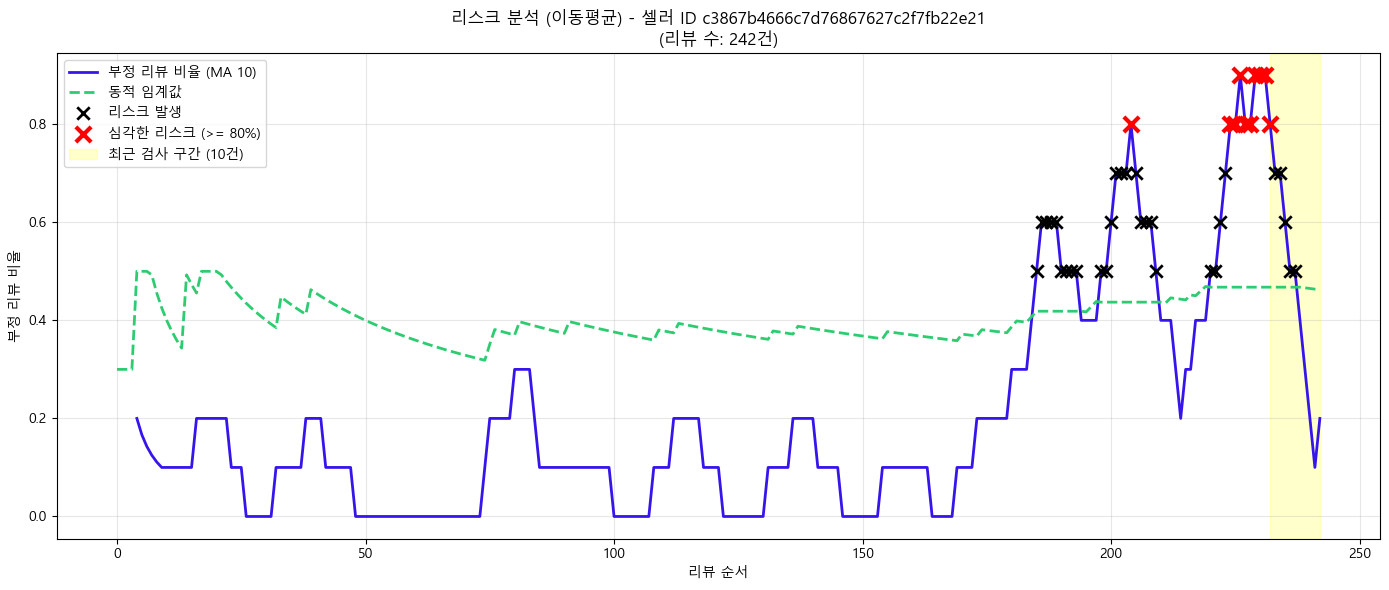

In [33]:
risk_analysis_unpolluted_plot('c3867b4666c7d76867627c2f7fb22e21')

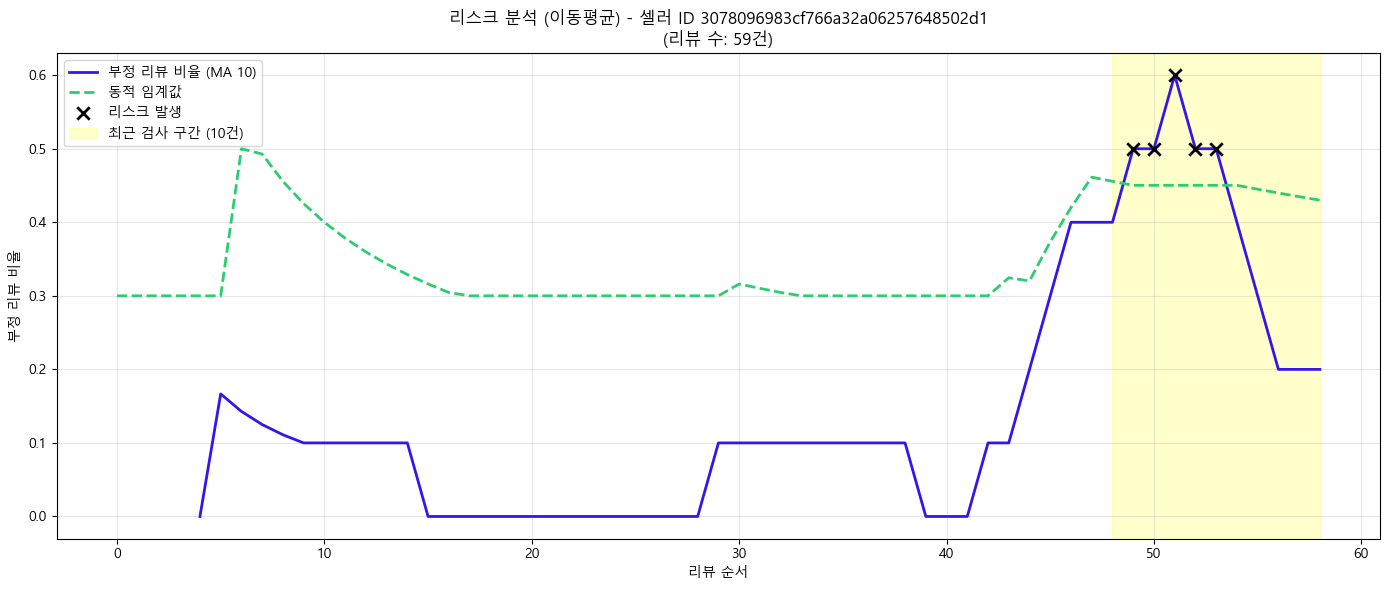

In [34]:
risk_analysis_unpolluted_plot('3078096983cf766a32a06257648502d1')

### 퍼센타일 임계값 계산


[seller_metrics 생성 완료]
(3088, 6)
                          seller_id     segment  delay_rate  cancel_rate  \
0  0015a82c2db000af6aaaf3ae2ecb0532         SMB    0.000000          0.0   
1  001cca7ae9ae17fb1caed9dfb1094831  Enterprise    0.061856          0.0   
2  001e6ad469a905060d959994f1b41e4f         SMB         NaN          1.0   
3  002100f778ceb8431b7a1020ff7ab48f         SMB    0.183673          0.0   
4  003554e2dce176b5555353e4f3555ac8         SMB    0.000000          0.0   

   avg_delay_days  total_orders  
0        0.000000             3  
1        0.728643           199  
2        0.000000             1  
3        1.340000            50  
4        0.000000             1  

[퍼센타일 기준 모집단]
리뷰 20건 이상 셀러 수: 811
퍼센타일 계산 대상 seller_metrics_20 셀러 수: 811

사용 가능한 segment: ['Enterprise', 'SMB']


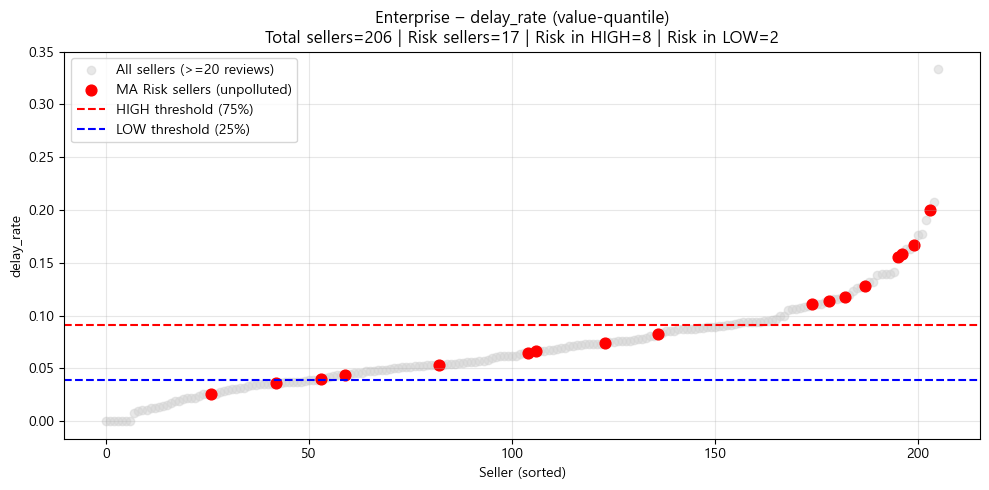

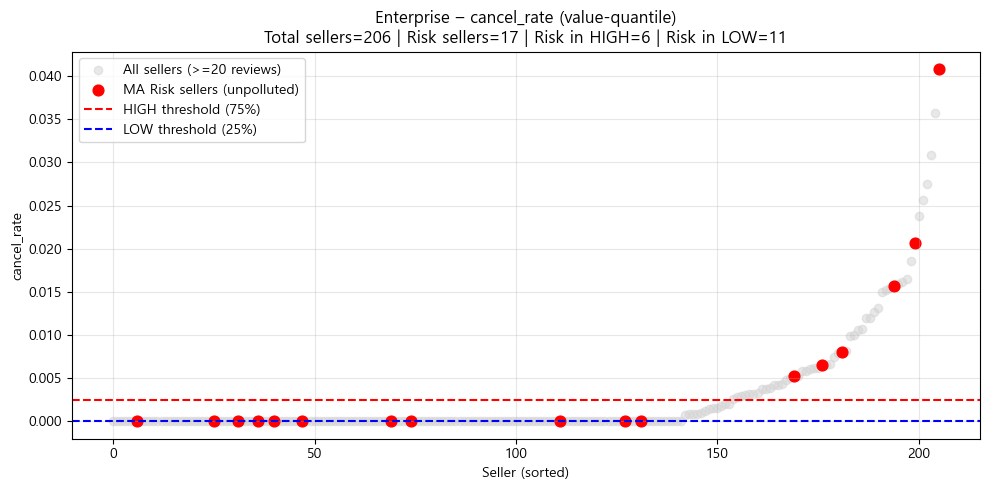

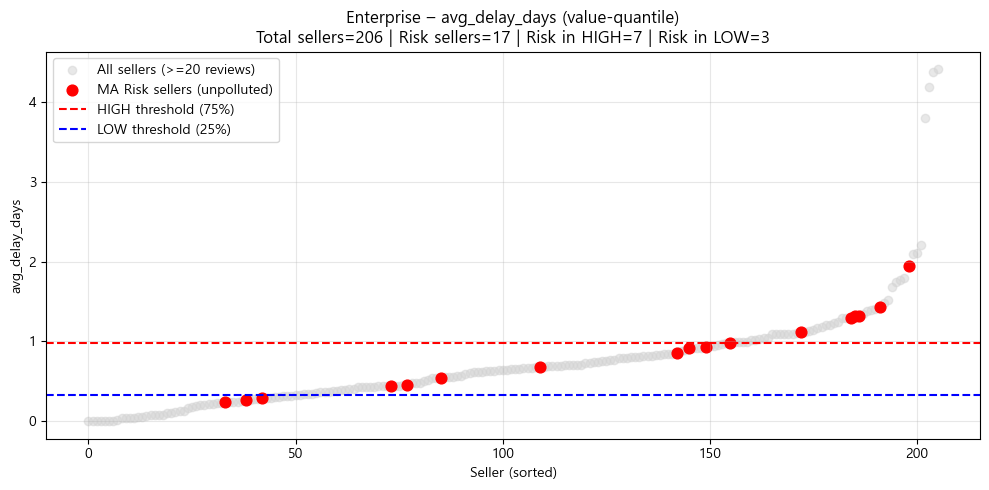

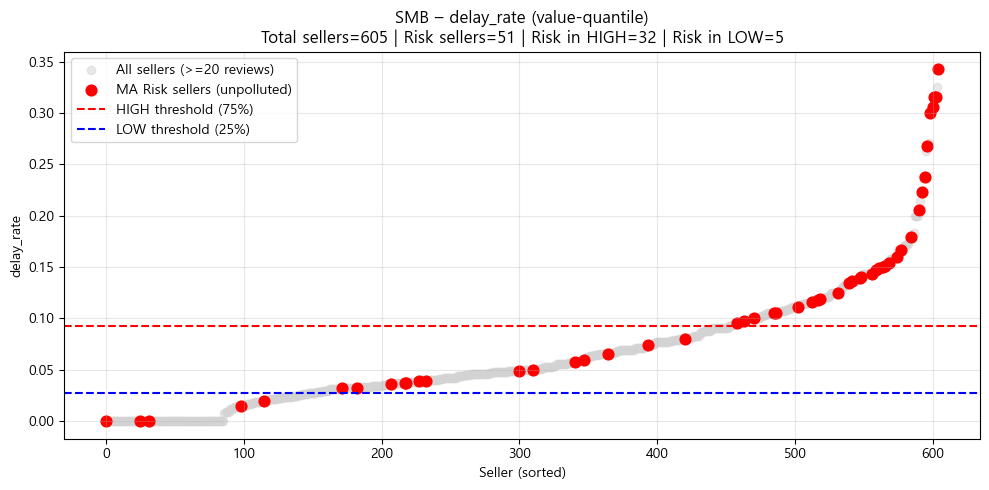

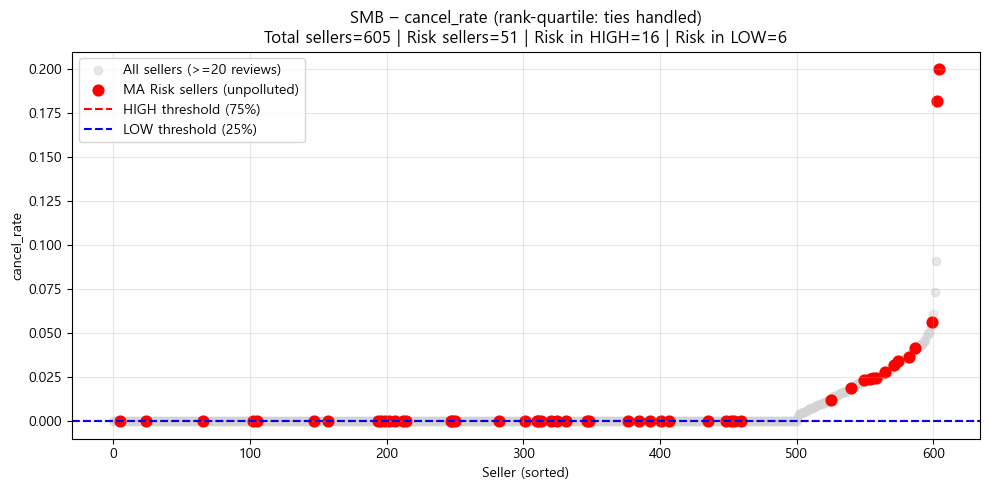

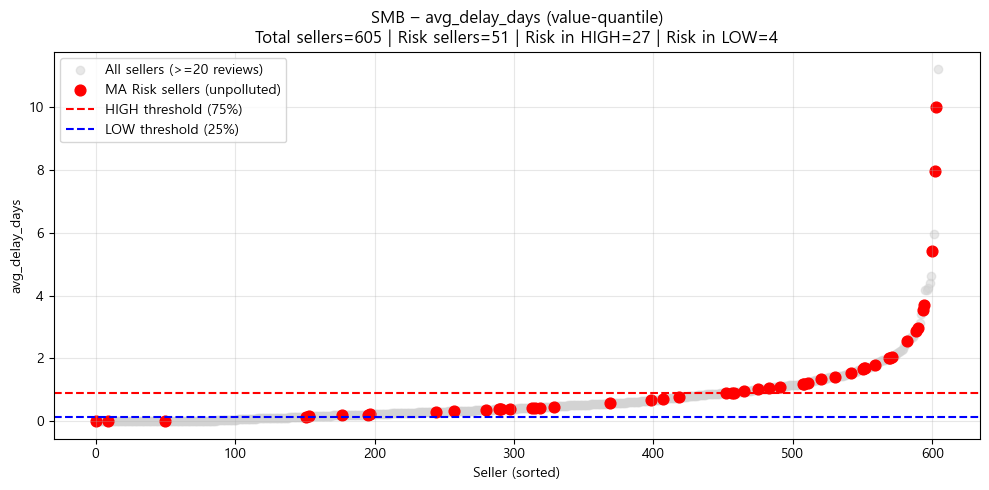


✅ 전체 파이프라인 완료!


In [ ]:
# =========================================================
# seller 운영지표(delay/cancel/avg_delay_days) 만들기
# =========================================================
df_tmp = df.copy()

need = ["seller_id", "segment", "order_id"]
miss = [c for c in need if c not in df_tmp.columns]
if miss:
    raise ValueError(f"df에 필수 컬럼이 없습니다: {miss}")

# 타입 통일
df_tmp["seller_id"] = df_tmp["seller_id"].astype(str)

# 1. is_delayed 생성
if "is_delayed" not in df_tmp.columns:
    if "delivery_delay_days" in df_tmp.columns:
        df_tmp["delivery_delay_days"] = pd.to_numeric(df_tmp["delivery_delay_days"], errors="coerce").fillna(0)
        df_tmp["is_delayed"] = (df_tmp["delivery_delay_days"] > 0).astype(int)
    elif ("order_delivered_customer_date" in df_tmp.columns) and ("order_estimated_delivery_date" in df_tmp.columns):
        df_tmp["order_delivered_customer_date"] = pd.to_datetime(df_tmp["order_delivered_customer_date"], errors="coerce")
        df_tmp["order_estimated_delivery_date"] = pd.to_datetime(df_tmp["order_estimated_delivery_date"], errors="coerce")
        delay_days = (df_tmp["order_delivered_customer_date"] - df_tmp["order_estimated_delivery_date"]).dt.days
        delay_days = delay_days.fillna(0).clip(lower=0)
        df_tmp["delivery_delay_days"] = delay_days
        df_tmp["is_delayed"] = (delay_days > 0).astype(int)
    else:
        raise ValueError("배송지연 계산 컬럼이 없습니다. (is_delayed 또는 delivery_delay_days 또는 delivered/estimated date 필요)")

# 2. is_canceled 생성
if "is_canceled" not in df_tmp.columns:
    if "order_status" in df_tmp.columns:
        df_tmp["is_canceled"] = df_tmp["order_status"].isin(["canceled", "unavailable"]).astype(int)
    else:
        raise ValueError("취소 여부 컬럼이 없습니다. (is_canceled 또는 order_status 필요)")

# 주문 단위로 중복 제거 후 집계
df_order = df_tmp.drop_duplicates(subset=["order_id"]).copy()

if "delivery_delay_days" in df_order.columns:
    df_order["delivery_delay_days"] = pd.to_numeric(df_order["delivery_delay_days"], errors="coerce").fillna(0).clip(lower=0)
else:
    df_order["delivery_delay_days"] = 0

seller_metrics = (
    df_order.groupby(["seller_id", "segment"], as_index=False)
    .agg(
        delay_rate=("is_delayed", "mean"),
        cancel_rate=("is_canceled", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        total_orders=("order_id", "nunique")
    )
)

print("\n[seller_metrics 생성 완료]")
print(seller_metrics.shape)
print(seller_metrics.head())

# =========================================================
# 퍼센타일(25/75) 기준을 '리뷰 20건 이상 셀러'로 제한해서 산점도
# =========================================================
# 1) 리뷰 20건 이상 셀러 리스트(리뷰 기준) 생성
MIN_REVIEWS = 20
seller_review_cnt = (
    df.dropna(subset=["review_id"])
      .groupby("seller_id")["review_id"]
      .nunique()
)

qualified_sellers_20 = seller_review_cnt[seller_review_cnt >= MIN_REVIEWS].index.astype(str)

print("\n[퍼센타일 기준 모집단]")
print("리뷰 20건 이상 셀러 수:", len(qualified_sellers_20))

# 2) 퍼센타일 계산용 df: seller_metrics에서 20건 이상만 남김
seller_metrics_20 = seller_metrics[
    seller_metrics["seller_id"].astype(str).isin(qualified_sellers_20)
].copy()

print("퍼센타일 계산 대상 seller_metrics_20 셀러 수:", seller_metrics_20["seller_id"].nunique())

# 3) 산점도 함수
def scatter_with_threshold_and_riskcount(df_in, metric, segment, risky_ids_in):
    d = df_in[df_in["segment"] == segment].sort_values(metric).reset_index(drop=True)
    risky_ids_in = set(map(str, risky_ids_in))

    if d.empty:
        print(f"[경고] segment='{segment}' 데이터가 없습니다.")
        return

    q25 = d[metric].quantile(0.25)
    q75 = d[metric].quantile(0.75)

    d["is_risky"] = d["seller_id"].astype(str).isin(risky_ids_in)
    n_total = d["seller_id"].nunique()
    n_risky = d["is_risky"].sum()

    # 0 몰림/동점폭발 대응
    if pd.isna(q25) or pd.isna(q75) or q25 == q75:
        d["_rank"] = d[metric].rank(method="first")
        d["_quartile"] = pd.qcut(d["_rank"], 4, labels=["LOW", "MID1", "MID2", "HIGH"])
        n_risky_high = ((d["_quartile"] == "HIGH") & d["is_risky"]).sum()
        n_risky_low  = ((d["_quartile"] == "LOW")  & d["is_risky"]).sum()
        mode_note = " (rank-quartile: ties handled)"
    else:
        n_risky_high = ((d[metric] >= q75) & d["is_risky"]).sum()
        n_risky_low  = ((d[metric] <= q25) & d["is_risky"]).sum()
        mode_note = " (value-quantile)"

    plt.figure(figsize=(10, 5))
    plt.scatter(d.index, d[metric], color="lightgray", alpha=0.5, label="All sellers (>=20 reviews)")
    r = d[d["is_risky"]]
    plt.scatter(r.index, r[metric], color="red", s=60, label="MA Risk sellers (unpolluted)")

    plt.axhline(q75, linestyle="--", color="red", label="HIGH threshold (75%)")
    plt.axhline(q25, linestyle="--", color="blue", label="LOW threshold (25%)")

    plt.title(
        f"{segment} – {metric}{mode_note}\n"
        f"Total sellers={n_total} | Risk sellers={n_risky} | "
        f"Risk in HIGH={n_risky_high} | Risk in LOW={n_risky_low}"
    )
    plt.xlabel("Seller (sorted)")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 4) 실행 예시: 3개 지표 x 세그먼트별
# =========================================================
segments = seller_metrics_20["segment"].dropna().unique().tolist()
print("\n사용 가능한 segment:", segments)

for seg in segments:
    scatter_with_threshold_and_riskcount(seller_metrics_20, "delay_rate", seg, risky_sellers_unpolluted_list)
    scatter_with_threshold_and_riskcount(seller_metrics_20, "cancel_rate", seg, risky_sellers_unpolluted_list)
    scatter_with_threshold_and_riskcount(seller_metrics_20, "avg_delay_days", seg, risky_sellers_unpolluted_list)

print("\n✅ 전체 파이프라인 완료!")

## ✅ 대시보드용 파일 1
`olist_risk_analysis_results_final.csv` 생성

In [ ]:
# 리스크 셀러 추출
recent_history = df_analysis.groupby('seller_id').tail(CHECK_RANGE)
risky_sellers_unpolluted_list = recent_history[recent_history['is_risk_triggered'] == True]['seller_id'].unique()

print(f"\n🚨 최근 위험 감지 셀러 수: {len(risky_sellers_unpolluted_list)}명")

# 태블로용 데이터 만들기
def avg_delay_only_delayed(x):
    """지연된 건(>0)들에 대해서만 평균을 구함. 지연 없으면 0."""
    delayed = x[x > 0]
    return delayed.mean() if not delayed.empty else 0.0

seller_info = df_analysis.groupby('seller_id').agg({
    'is_delayed': 'mean',              
    'delivery_delay_days': avg_delay_only_delayed,             
    'is_canceled': 'mean',             
    'is_negative': ['sum', 'mean'],   
    'order_id': 'nunique',
    'review_id': 'nunique',           
})

# Multi-index 컬럼 정리
seller_info.columns = ['_'.join(col).strip() if col[1] else col[0] for col in seller_info.columns.values]

seller_info = seller_info.rename(columns={
    'is_delayed_mean': 'delay_rate',                                  # 지연율
    'delivery_delay_days_avg_delay_only_delayed': 'avg_delay_days',   # 평균 지연 일수
    'is_canceled_mean': 'cancel_rate',                                # 취소율
    'is_negative_sum': 'negative_review_count',                       # 부정리뷰 개수
    'is_negative_mean': 'negative_review_rate',                       # 부정리뷰 비율
    'order_id_nunique': 'order_count',                                # 주문 수
    'review_id_nunique': 'review_count',                              # 리뷰 수
}).reset_index()

df_analysis['is_risk_seller'] = df_analysis['seller_id'].isin(risky_sellers_unpolluted_list)

# 4) 리뷰 순서(Sequence) 컬럼 생성
df_analysis['review_sequence'] = df_analysis.groupby('seller_id').cumcount() + 1

# 5) 리스크 포인트 시각화용 컬럼 생성
# 리스크가 발생한 지점(True)은 값을 남기고, 아니면 NULL(비워둠) 처리
df_analysis['risk_point'] = df_analysis.apply(
    lambda x: x['current_ma'] if x['is_risk_triggered'] else None, axis=1
)

# 병합
df_tab = pd.merge(df_analysis, seller_info, on='seller_id', how='left')

# order_item_id 기준 중복 제거
df_tab_dup = df_tab[df_tab['order_item_id'] == 1]

# 6) 필요한 컬럼만 선택하여 저장
export_cols = [
    'seller_id', 
    'order_id',
    'order_item_id',
    'order_purchase_timestamp', 
    'review_sequence',      # 이동평균 X축
    'is_negative', 
    'current_ma',      
    'final_threshold',    
    'is_risk_triggered',  
    'risk_point',           # 리스크 지점
    'is_risk_seller',
    'delay_rate',
    'is_delayed',
    'delivery_delay_days',
    'avg_delay_days',
    'cancel_rate',
    'is_canceled',
    'negative_review_rate',
    'negative_review_count',
    'order_count',
    'review_count',
    'segment'    
]

# CSV 파일로 저장
# df_tab_dup[export_cols].to_csv('olist_risk_analysis_results_final.csv', index=False, encoding='utf-8-sig')
# print("✅ olist_risk_analysis_results_final.csv 저장")


🚨 최근 위험 감지 셀러 수: 68명


# 4️⃣ 토픽모델링 및 워드클라우드

## 1. 부정 리뷰만 필터링

In [37]:
sentiment_target_final = pd.read_csv("sentiment_target_final.csv", index_col=0)

In [38]:
sentiment_target_final.columns

Index(['review_id', 'review_comment_translated', 'review_score', 'bert_star',
       'hybrid_score', 'final_label'],
      dtype='object')

In [39]:
# Negative만 사용
neg_df = sentiment_target_final[sentiment_target_final["final_label"] == "negative"].copy()

# 텍스트 컬럼
docs = neg_df["review_comment_translated"].astype(str).tolist()
print("부정 리뷰 수:", len(docs))

부정 리뷰 수: 12071


In [40]:
df_topic = sentiment_target_final.copy()

In [41]:
print(df_topic.info())

# Negative만 사용
neg_df = df_topic[df_topic["final_label"] == "negative"].copy()

# 텍스트 컬럼
docs = neg_df["review_comment_translated"].astype(str).tolist()
print("\n부정 리뷰 수:", len(docs))

<class 'pandas.core.frame.DataFrame'>
Index: 40912 entries, 0 to 112648
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   review_id                  40912 non-null  object 
 1   review_comment_translated  40912 non-null  object 
 2   review_score               40912 non-null  float64
 3   bert_star                  40912 non-null  int64  
 4   hybrid_score               40912 non-null  float64
 5   final_label                40912 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 2.2+ MB
None

부정 리뷰 수: 12071


## 2. 임베딩 모델 로드 및 토픽모델링

In [42]:
# ==============================================
# 임베딩 모델 로드
# ==============================================
from sentence_transformers import SentenceTransformer

print("임베딩 모델 로드 중: BAAI/bge-large-en-v1.5")
embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")
print("임베딩 차원:", embedding_model.get_sentence_embedding_dimension())

임베딩 모델 로드 중: BAAI/bge-large-en-v1.5
임베딩 차원: 1024


In [43]:
def prepare_embeddings(texts, model):
    return model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )

print("임베딩 생성 중...")
embeddings = prepare_embeddings(docs, embedding_model)
print("임베딩 shape:", embeddings.shape)

임베딩 생성 중...


Batches: 100%|██████████| 378/378 [11:02<00:00,  1.75s/it]

임베딩 shape: (12071, 1024)


In [44]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

english_stopwords = text.ENGLISH_STOP_WORDS

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85
)

In [45]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

def create_bertopic_model(n_neighbors=15, min_cluster_size=60):
    return BERTopic(
        embedding_model=embedding_model,
        
        umap_model=UMAP(
            n_neighbors=n_neighbors,
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=42 
        ),
        
        hdbscan_model=HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=3,
            metric="euclidean",
            prediction_data=True
        ),
        
        vectorizer_model=vectorizer_model,
        verbose=True
    )

In [46]:
# 12k negative 리뷰 → min_cluster_size 50~120 추천
topic_model = create_bertopic_model(
    n_neighbors=15,
    min_cluster_size=60
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

topic_info = topic_model.get_topic_info()
print(topic_info.head(20))

2025-12-28 23:37:39,872 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-28 23:37:59,070 - BERTopic - Dimensionality - Completed ✓
2025-12-28 23:37:59,071 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-28 23:37:59,286 - BERTopic - Cluster - Completed ✓
2025-12-28 23:37:59,289 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-28 23:37:59,426 - BERTopic - Representation - Completed ✓


    Topic  Count                                               Name  \
0      -1   3694              -1_return_does_received product_wrong   
1       0   1149                 0_units_bought products_unit_items   
2       1    664      1_lannister_targaryen_stores_lannister stores   
3       2    523  2_product arrived_product delivered_arrived pr...   
4       3    425                     3_post office_office_post_mail   
5       4    403             4_quality_quality product_material_bad   
6       5    368             5_broken_came broken_damaged_packaging   
7       6    320                6_defect_defective_work_came defect   
8       7    314  7_product bought_different_bought product_wron...   
9       8    234                           8_clock_watch_silver_box   
10      9    229  9_canceled_cancellation_cancel_requested cance...   
11     10    221  10_waiting product_product waiting_waiting del...   
12     11    205                   11_long_took_long time_took long   
13    

In [47]:
print("[부정 리뷰 토픽별 키워드]")
print("=" * 60)

for topic_id in sorted(topic_info["Topic"].unique()):
    if topic_id == -1:
        continue
    
    keywords = topic_model.get_topic(topic_id)
    count = topic_info[topic_info["Topic"] == topic_id]["Count"].values[0]

    print(f"\n 토픽 {topic_id} ({count}개 리뷰)")
    print("-" * 40)
    for word, score in keywords[:7]:
        print(f"  {word}: {score:.4f}")

[부정 리뷰 토픽별 키워드]

 토픽 0 (1149개 리뷰)
----------------------------------------
  units: 0.0618
  bought products: 0.0357
  unit: 0.0355
  items: 0.0317
  bought units: 0.0275
  products received: 0.0257
  purchased: 0.0234

 토픽 1 (664개 리뷰)
----------------------------------------
  lannister: 0.1036
  targaryen: 0.0593
  stores: 0.0406
  lannister stores: 0.0366
  baratheon: 0.0320
  website: 0.0256
  com: 0.0248

 토픽 2 (523개 리뷰)
----------------------------------------
  product arrived: 0.0573
  product delivered: 0.0481
  arrived product: 0.0400
  position: 0.0333
  far product: 0.0307
  delivery time: 0.0298
  received order: 0.0295

 토픽 3 (425개 리뷰)
----------------------------------------
  post office: 0.1105
  office: 0.1102
  post: 0.1100
  mail: 0.0518
  freight: 0.0442
  home: 0.0394
  residence: 0.0369

 토픽 4 (403개 리뷰)
----------------------------------------
  quality: 0.1197
  quality product: 0.0604
  material: 0.0582
  bad: 0.0550
  poor: 0.0521
  poor quality: 0.0519
  low:

In [48]:
def sample_reviews(topic_id, n=5):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    samples = neg_df.iloc[idx].head(n)["review_comment_translated"].tolist()

    print(f"\n=== Topic {topic_id} 샘플 리뷰 ===")
    for s in samples:
        print("-", s)

sample_reviews(0)


=== Topic 0 샘플 리뷰 ===
- I bought two backpacks and I received only one product is the value you are charging two products queto return of the product is my reimbursement
- I bought 4 agaves only came one
- I placed a order of 4 items, it was separated into 2 deliveries. I only received 3 items !!!
- The purchased kit had 8 modules and only 7 came. I sent one and mail to the supplier and so far I haven't gotten an answer.
- I bought 2 (two) tablet qbex zupin tx120 7 "4gb dual core Android 4.2 black and received only 1 (one). The invoice has 2 units, but in the sealed box there was only 1 (one). I consider myself stolen.


### 2-1) 간단 워드 클라우드 생성

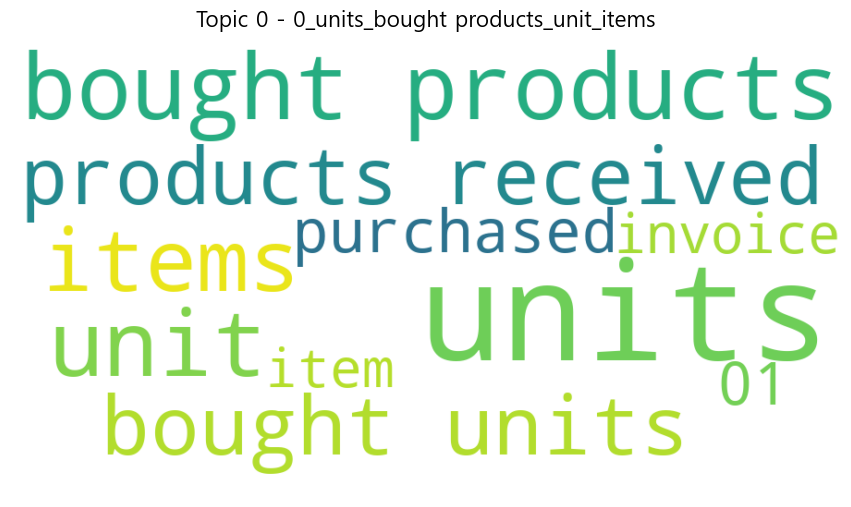

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_topic_label(topic_id):
    info = topic_model.get_topic_info()
    row = info[info["Topic"] == topic_id]
    if row.empty:
        return f"Topic {topic_id}"
    return row["Name"].values[0]

def wordcloud_for_topic(topic_id):
    words = topic_model.get_topic(topic_id)
    if not words:
        return
    
    freq = {w: float(s) for w, s in words}

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        prefer_horizontal=0.9,
        collocations=False
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id} - {get_topic_label(topic_id)}", fontsize=16)
    plt.show()

wordcloud_for_topic(0)

### 2-2) 토픽 분류

In [50]:
# 1) 세부 토픽 레벨
topic_labels = {
    # A. 제품 미수령 / 부분배송 / 누락
    0: "[A] 미수령·부분배송/누락 (units, items 이슈)",
    12: "[A] 제품 미수령 (didn't receive)",
    15: "[A] 구성품 누락·부분배송 (missing/incomplete)",
    21: "[A] 제품 미수령 (haven't received)",
    24: "[A] 평가 불가(미수령 상태)",
    28: "[A] 부분배송·반만 도착 (half/partially)",
    37: "[A] 제품 미수령 (did not receive)",
    38: "[A] 제품 미수령 (haven't received)",
    
    # B. 오배송 / 옵션·색상 오류
    7:  "[B] 다른 상품 도착 (wrong/different product)",
    13: "[B] 사진·상세와 다른 상품 (photo vs reality)",
    23: "[B] 색상 오배송 (wrong color)",
    27: "[B] 오배송 + 반품/교환 요청",
    
    # C. 품질·파손·불량·가품
    4:  "[C] 저품질·재질 불만 (quality/material)",
    5:  "[C] 파손·포장 불량 (broken/box)",
    6:  "[C] 제품 불량·작동 안됨 (defective/does not work)",
    8:  "[C] 시계류 품질·불량 (clock/watch)",
    22: "[C] 가품/정품 의심 (fake/counterfeit)",
    33: "[C] 의자 마감·품질 불만 (chairs/finish)",
    
    # D. 배송 지연 / 장기대기 / 기한 초과
    2:  "[D] 배송 완료 처리 vs 실제 수령 문제",
    10: "[D] 배송 대기 상태 (waiting product)",
    11: "[D] 배송이 너무 오래 걸림 (long time)",
    18: "[D] 배송 기한 초과 (deadline passed)",
    19: "[D] 배송 시간 지연 (delivery time/date)",
    30: "[D] 수십일 이상 장기 지연 (20·30 days)",
    36: "[D] 배송 지연 명시적 불만 (delivery delay)",
    32: "[D] 날짜/기한 관련 불만",
    
    # E. 배송 주체/파트너 문제
    1:  "[E] 특정 파트너사/마켓플레이스 이슈 (lannister/targaryen)",
    3:  "[E] 우체국/택배사 문제 (post office/mail)",
    
    # F. 취소·환불·반품
    9:  "[F] 주문 취소·취소 요청 (cancellation)",
    34: "[F] 환불·입금 반환 문제 (money/refund)",
    
    # G. 카테고리 특화 문제 (특정 상품군)
    16: "[G] 프린터 카트리지·토너 이슈",
    20: "[G] 조명/램프 상품 이슈",
    25: "[G] 커튼/침실 소품 이슈",
    29: "[G] 침구/베딩·게임 시트 이슈",
    39: "[G] 보충제·Whey 등 이슈",
    
    # H. 감정·일반 불만 / 애매한 리뷰
    14: "[H] 내용은 괜찮지만 점수는 낮음(혼합 평가)",
    17: "[H] 강한 부정 감정 표현 (bad/terrible)",
    31: "[H] 재구매/추천 의사 관련 불만",
    26: "[H] 사이트 상태 vs 실제 배송 상태 괴리",
}

# BERTopic 라벨 적용
topic_model.set_topic_labels(topic_labels)

# 확인
topic_model.get_topic_info().head(10)

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,3694,-1_return_does_received product_wrong,-1_return_does_received product_wrong,"[return, does, received product, wrong, haven,...",[Mousse does not foam must be with problem how...
1,0,1149,0_units_bought products_unit_items,"[A] 미수령·부분배송/누락 (units, items 이슈)","[units, bought products, unit, items, bought u...","[I bought 2 units, however, I only received 1 ..."
2,1,664,1_lannister_targaryen_stores_lannister stores,[E] 특정 파트너사/마켓플레이스 이슈 (lannister/targaryen),"[lannister, targaryen, stores, lannister store...","[I never buy at Lannister again, I am responsi..."
3,2,523,2_product arrived_product delivered_arrived pr...,[D] 배송 완료 처리 vs 실제 수령 문제,"[product arrived, product delivered, arrived p...","[Product has not arrived yet, The product has ..."
4,3,425,3_post office_office_post_mail,[E] 우체국/택배사 문제 (post office/mail),"[post office, office, post, mail, freight, hom...","[Since 16/10, which is in transition through t..."
5,4,403,4_quality_quality product_material_bad,[C] 저품질·재질 불만 (quality/material),"[quality, quality product, material, bad, poor...","[Poor quality product and finishing., I receiv..."
6,5,368,5_broken_came broken_damaged_packaging,[C] 파손·포장 불량 (broken/box),"[broken, came broken, damaged, packaging, prod...","[This product came broken I want another, Prod..."
7,6,320,6_defect_defective_work_came defect,[C] 제품 불량·작동 안됨 (defective/does not work),"[defect, defective, work, came defect, does wo...","[The product came with defect!, The product ca..."
8,7,314,7_product bought_different_bought product_wron...,[B] 다른 상품 도착 (wrong/different product),"[product bought, different, bought product, wr...",[I do not recommend because my order came wron...
9,8,234,8_clock_watch_silver_box,[C] 시계류 품질·불량 (clock/watch),"[clock, watch, silver, box, defective, manual,...","[It came only one clock., The clock was not de..."


In [51]:
# 2) 8개 대분류 정의
topic_groups = {
    "A_미수령·부분배송/누락":   [0, 12, 15, 21, 24, 28, 37, 38],
    "B_오배송·옵션오류":        [7, 13, 23, 27],
    "C_품질·파손·불량·가품":    [4, 5, 6, 8, 22, 33],
    "D_배송지연·기한초과":      [2, 10, 11, 18, 19, 30, 32, 36],
    "E_배송주체·파트너이슈":    [1, 3],
    "F_취소·환불·반품":         [9, 34],
    "G_카테고리특화상품이슈":   [16, 20, 25, 29, 39],
    "H_감정적·기타불만":        [14, 17, 26, 31],
}

# 토픽 → 대분류 매핑 dict 생성
topic_to_group = {}
for group_name, ids in topic_groups.items():
    for tid in ids:
        topic_to_group[tid] = group_name

# 문서 레벨에 대분류 붙이기 
neg_df = neg_df.copy()
neg_df["topic_id"] = topics
neg_df["topic_group"] = neg_df["topic_id"].map(topic_to_group).fillna("Z_기타")

neg_df["topic_group"].value_counts()

topic_group
Z_기타             3768
A_미수령·부분배송/누락    2016
C_품질·파손·불량·가품    1527
D_배송지연·기한초과      1488
E_배송주체·파트너이슈     1089
B_오배송·옵션오류        739
G_카테고리특화상품이슈      586
H_감정적·기타불만        553
F_취소·환불·반품        305
Name: count, dtype: int64

## 3. 워드 클라우드

### 3-1) 워드 클라우드 1차 수행

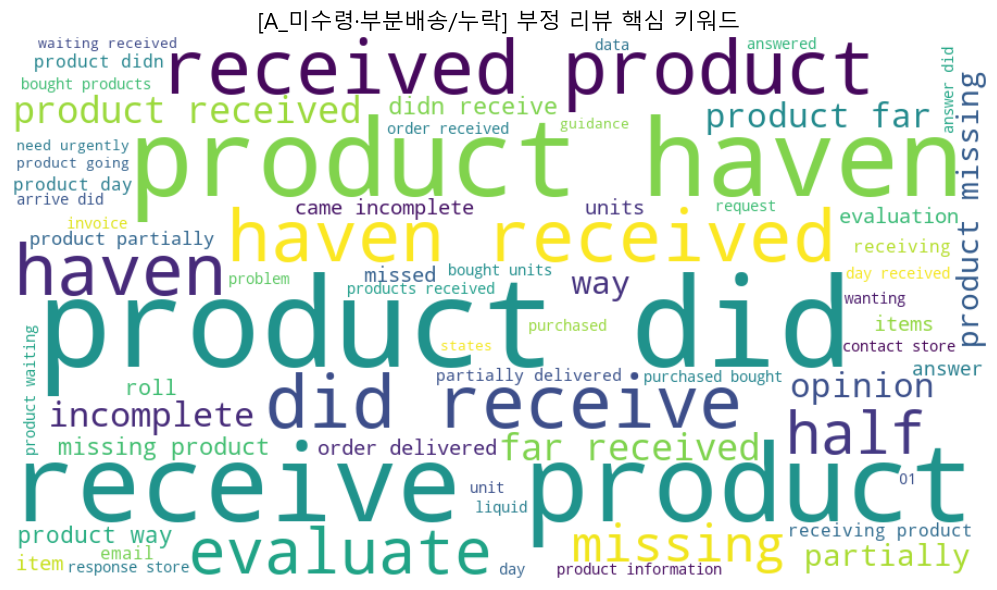

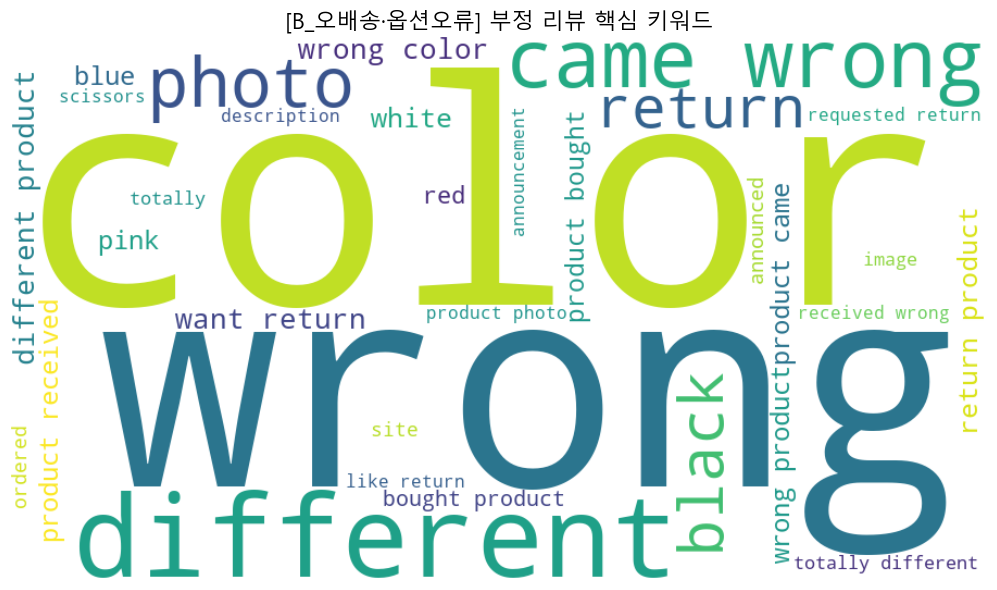

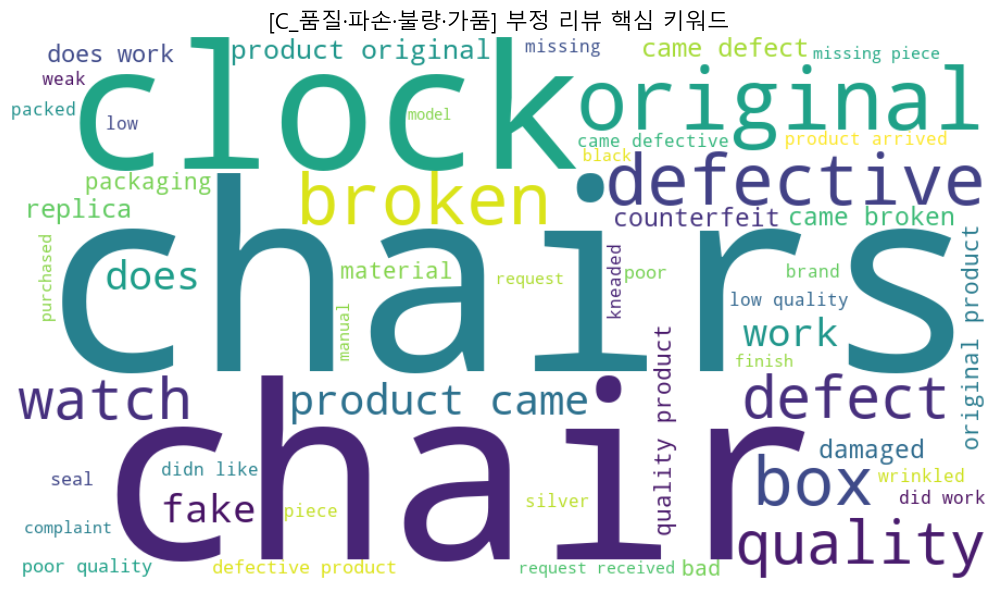

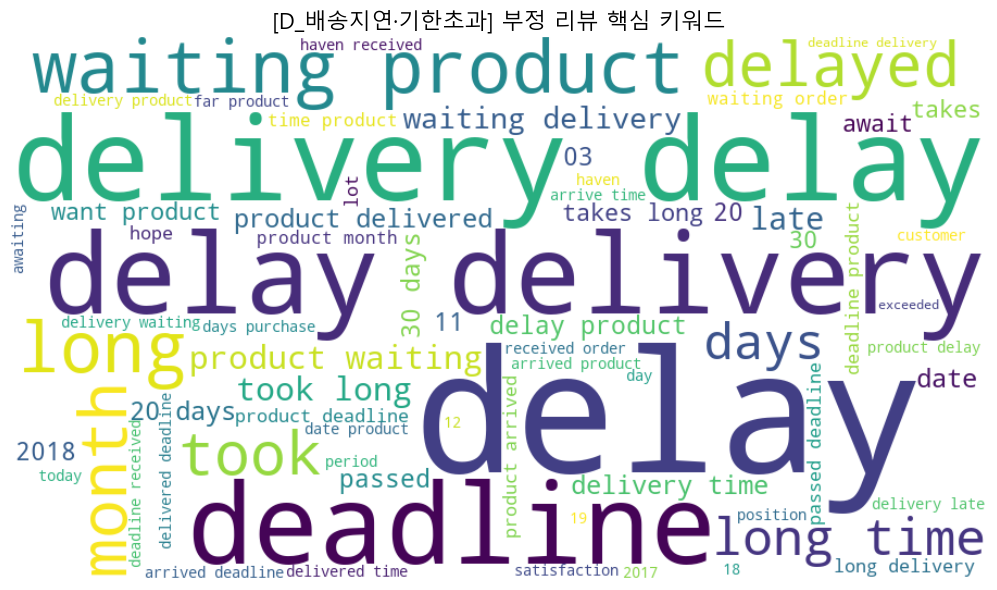

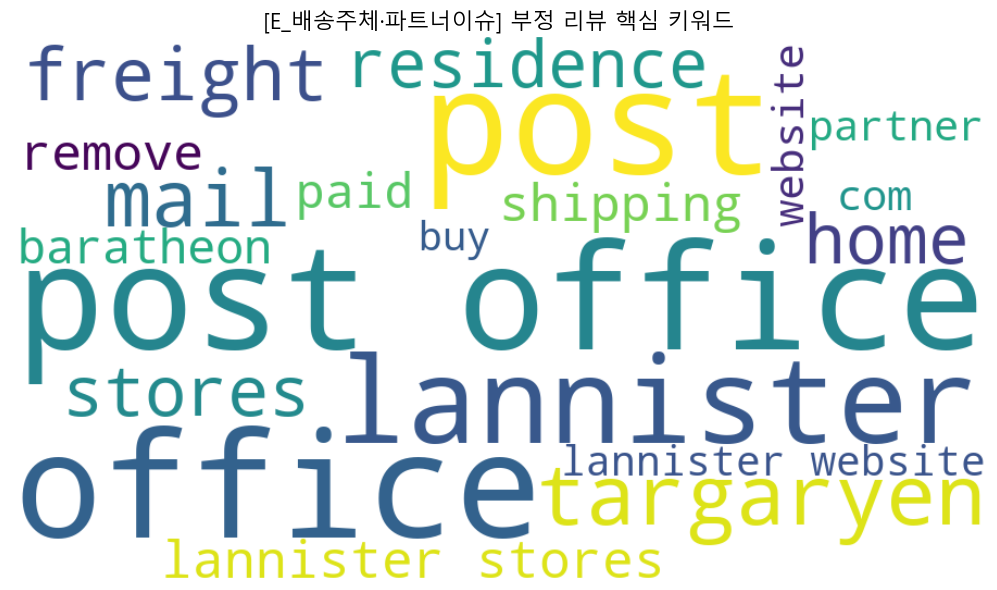

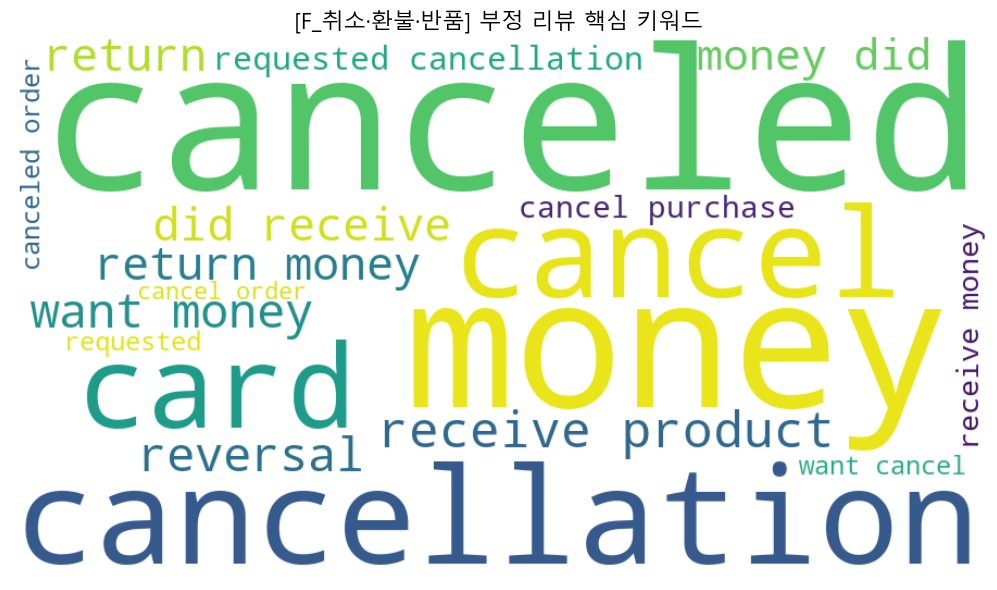

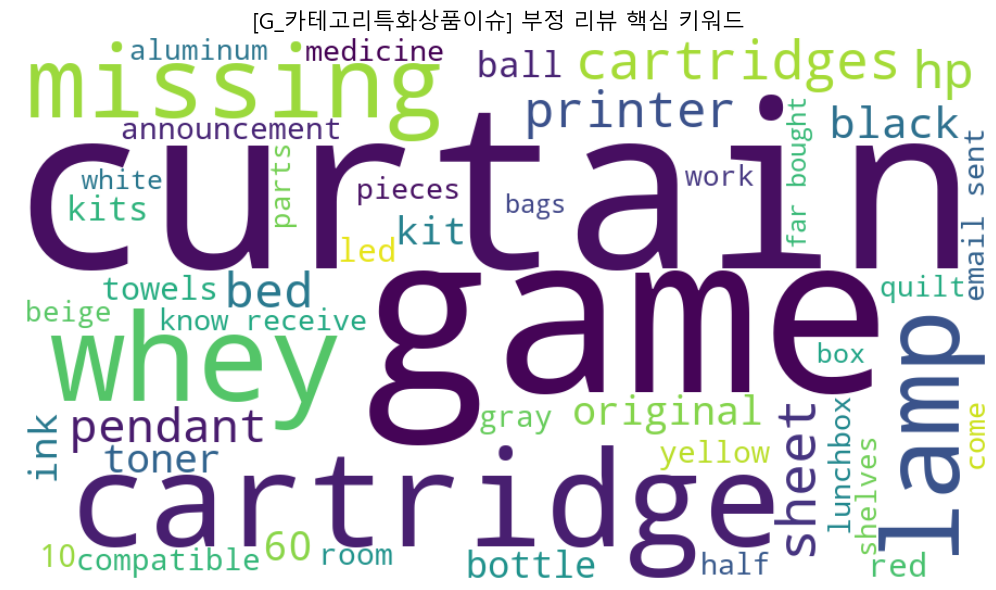

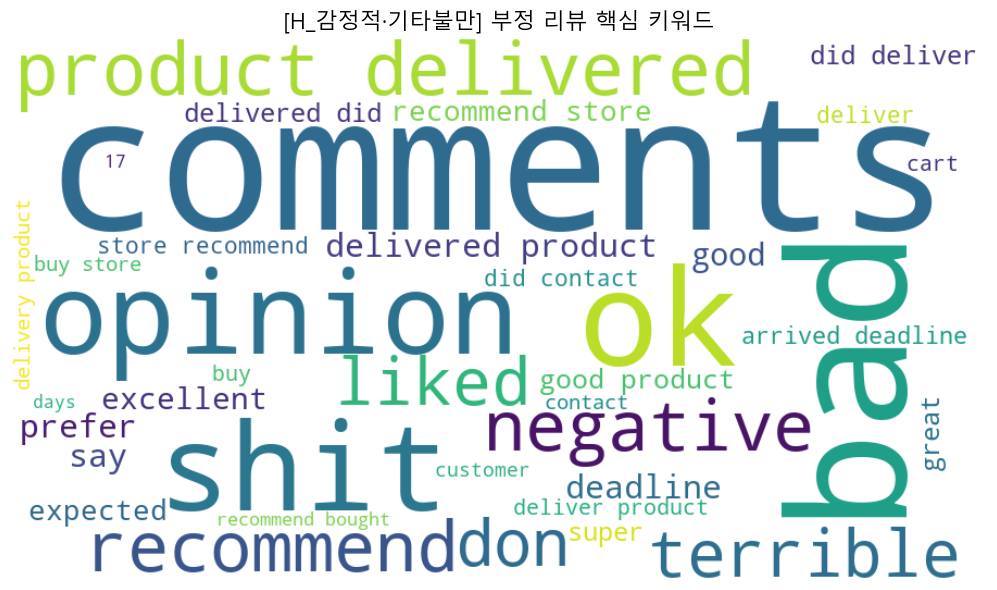

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def make_group_wordcloud(group_name, topic_ids, max_words=80):
    """
    하나의 대분류(group)에 포함된 여러 토픽의 키워드를 합쳐서 워드클라우드 생성
    """
    freq = {}

    for tid in topic_ids:
        words = topic_model.get_topic(tid)
        if not words:
            continue
        for w, score in words:
            w = str(w)
            freq[w] = freq.get(w, 0) + float(score)

    if not freq:
        print(f"[{group_name}] 단어 없음")
        return
    
    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        max_words=max_words,
        prefer_horizontal=0.9,
        collocations=False
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(11, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"[{group_name}] 부정 리뷰 핵심 키워드", fontsize=16)
    plt.tight_layout()
    plt.show()

# 8개 대분류 모두 워드클라우드 생성
for group_name, tids in topic_groups.items():
    make_group_wordcloud(group_name, tids)

### 3-2) 워드 클라우드 보강

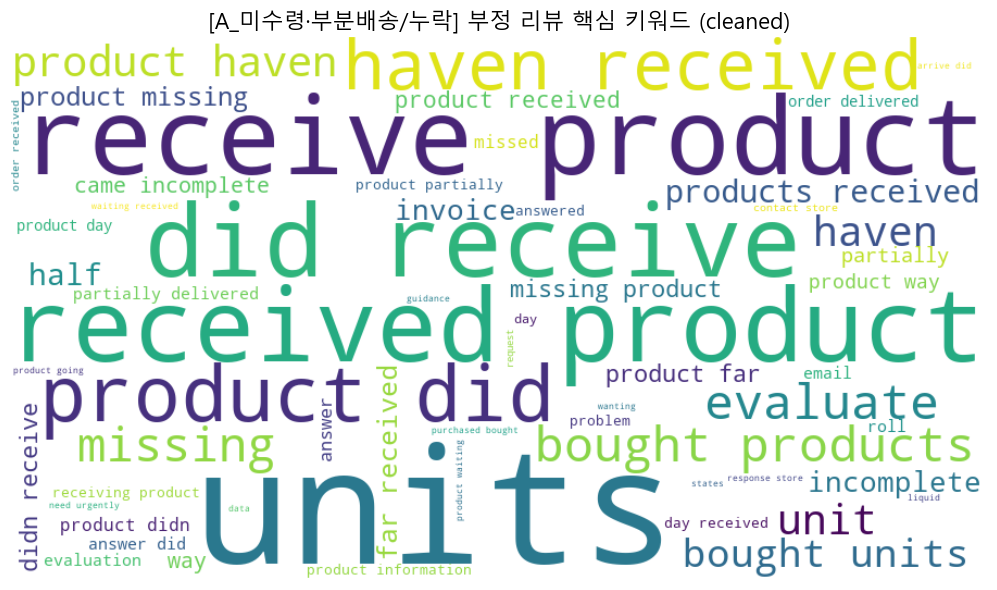

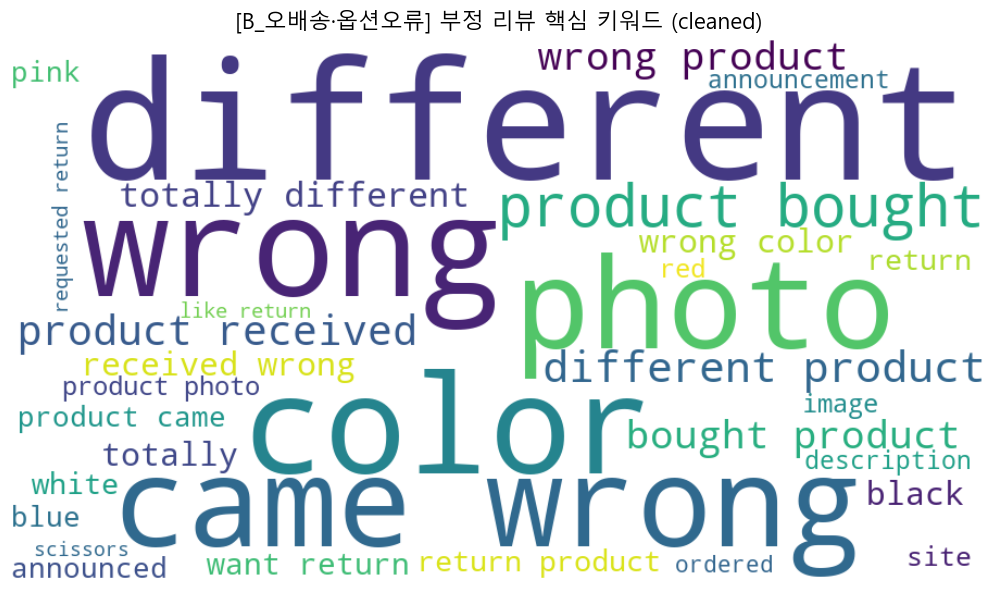

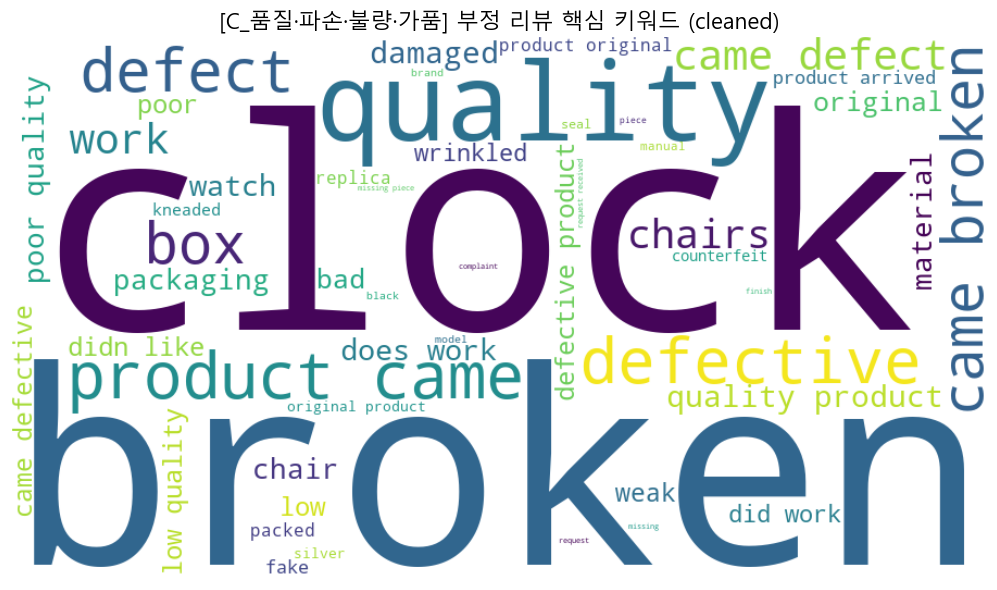

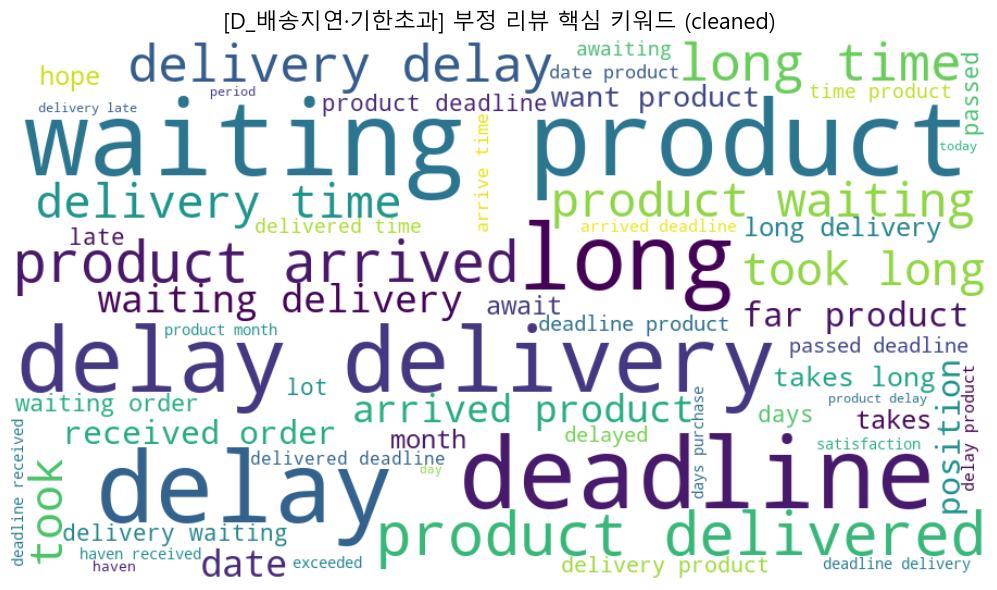

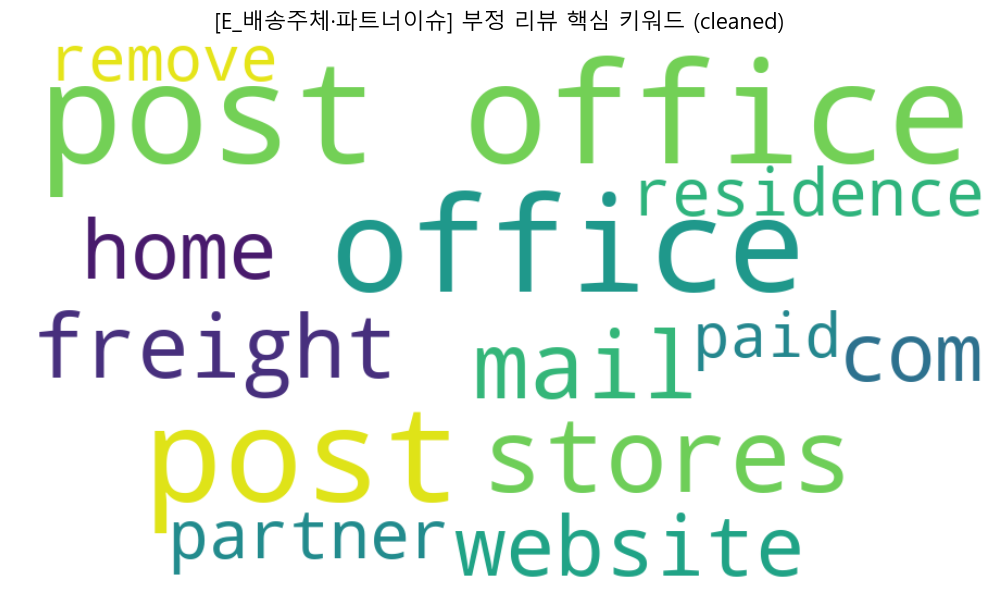

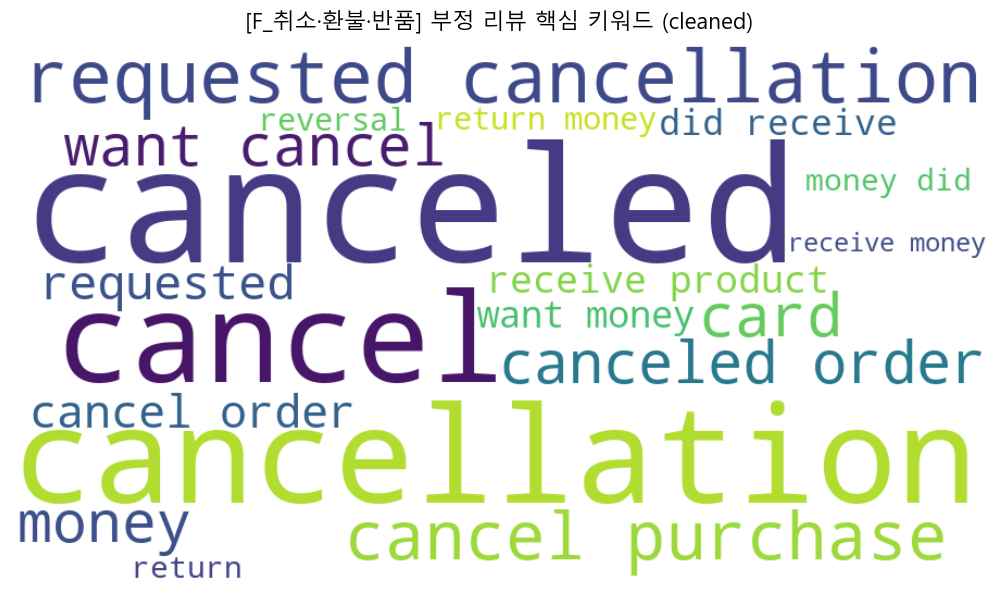

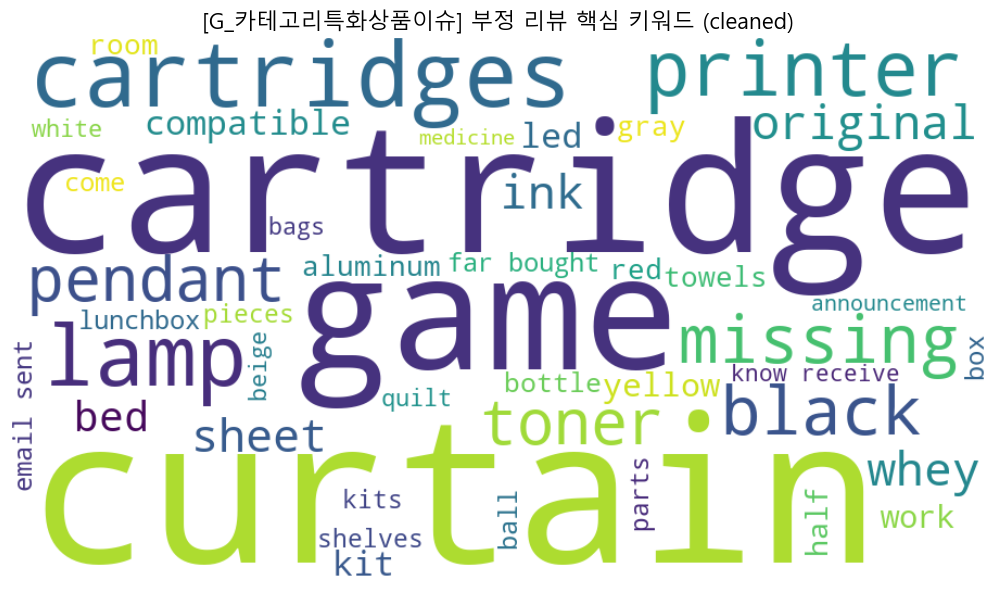

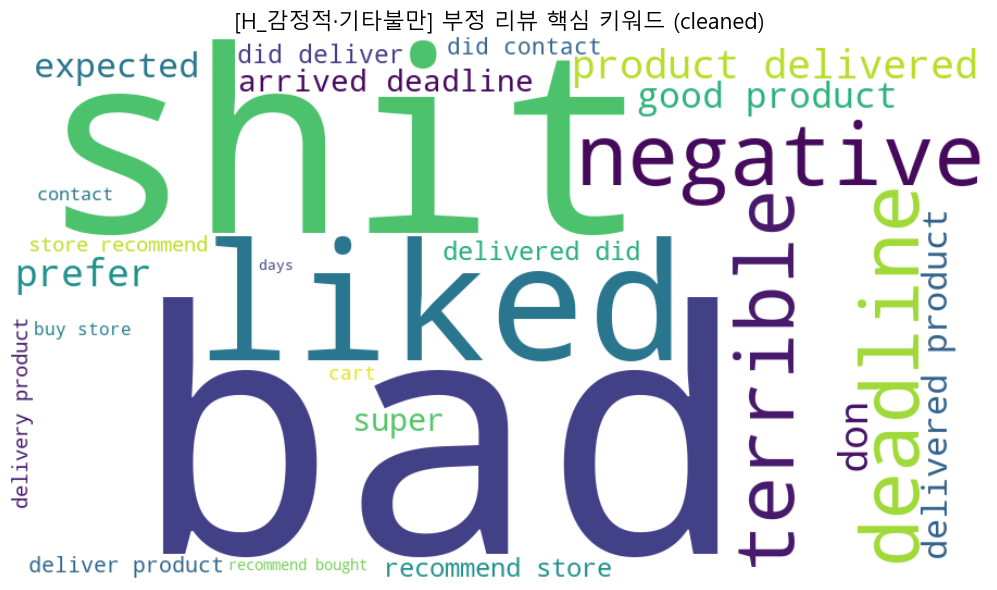

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction import text

# =========================================================
# 0) 그룹 워드클라우드용 보강 설정
# =========================================================

# (A) 기본 English stopwords + 도메인 커스텀 stopwords
english_stopwords = set(text.ENGLISH_STOP_WORDS)

domain_stopwords = {
    # 너무 일반적인 리뷰 단어들 (정보량 낮아서 워드클라우드 망침)
    "product","products","item","items","order","orders",
    "buy","bought","purchase","purchased","store","seller","customer",
    "comment","comments","opinion","review","reviews",
    "good","great","excellent","ok","nice","recommend","recommended",
    "get","got","getting",
    "say","said",
    # receive 류 (A토픽에서 너무 과도하게 커짐)
    "receive","received","receiving","did","didn","dont","does","doesn",
    "cant","won","would","could","im","ive","youre","theyre","thats",
    # 배송 일반 단어 (D/E에서 너무 일반적인 단어는 줄이는 용도)
    "delivery","delivered","deliver","shipping","shipped",
}

# (B) 특정 고유명사/밈 토큰 필터 (원하면 추가 가능)
banned_tokens = {"lannister", "targaryen", "baratheon"}

def normalize_token(w: str) -> str:
    """소문자화 + 공백 정리 + 구두점 제거(알파벳/숫자/공백/언더스코어만 남김)"""
    w = str(w).lower().strip()
    w = re.sub(r"[^\w\s]", "", w)   # ✅ 구두점 제거
    w = re.sub(r"\s+", " ", w)      # 공백 정리
    return w

def contains_banned(w: str) -> bool:
    """unigram/bigram/trigram 어디든 banned 토큰이 포함되면 True"""
    parts = w.split()
    return any(bt in parts for bt in banned_tokens)

def is_bad_token(w: str) -> bool:
    """너무 짧음/숫자 포함/특수문자/stopword/banned 포함 등 제거"""
    if not w:
        return True
    if len(w) <= 2:
        return True
    # 숫자 포함 제거 (원치 않으면 주석 처리)
    if re.search(r"\d", w):
        return True
    # 특수문자/기호만 있는 토큰 제거 (normalize_token에서 대부분 제거되지만 안전장치)
    if re.fullmatch(r"[\W_]+", w):
        return True
    # banned 토큰 포함 제거 (bigram에도 적용)
    if contains_banned(w):
        return True
    # stopwords 제거
    if w in english_stopwords or w in domain_stopwords:
        return True
    return False

# =========================================================
# 1) 개선된 그룹 워드클라우드 함수 (완성형)
# =========================================================
def make_group_wordcloud(
    group_name,
    topic_ids,
    topic_model,
    topic_info=None,
    max_words=80,
    width=900,
    height=500,
    background_color="white",
    prefer_horizontal=0.9,
    collocations=False,
    use_topic_count_weight=True,   # ✅ 토픽 리뷰 수(Count) 가중
    ngram_prefer=2,                # ✅ bigram 약간 우대
):
    """
    대분류(group)에 포함된 여러 토픽의 키워드를 합쳐 워드클라우드 생성 (완성형)

    - c-TF-IDF score를 단순 합산하지 않고, 토픽 Count로 가중치 적용
    - 커스텀 stopwords + 정규화 + banned 토큰 필터
    - bigram 우대 옵션
    """

    if topic_info is None:
        topic_info = topic_model.get_topic_info()

    topic_counts = {}
    if "Topic" in topic_info.columns and "Count" in topic_info.columns:
        topic_counts = topic_info.set_index("Topic")["Count"].to_dict()

    freq = {}

    for tid in topic_ids:
        words = topic_model.get_topic(tid)
        if not words:
            continue

        w_topic = topic_counts.get(tid, 1) if use_topic_count_weight else 1

        for w, score in words:
            w = normalize_token(w)

            # ngram 우대 (bigram이면 가중치 조금 추가)
            w_ngram = 1.0
            if ngram_prefer == 2 and " " in w:
                w_ngram = 1.15
            elif ngram_prefer == 1 and " " not in w:
                w_ngram = 1.05

            if is_bad_token(w):
                continue

            freq[w] = freq.get(w, 0.0) + float(score) * float(w_topic) * float(w_ngram)

    if not freq:
        print(f"[{group_name}] 단어 없음 (필터링으로 모두 제거됨)")
        return

    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        max_words=max_words,
        prefer_horizontal=prefer_horizontal,
        collocations=collocations
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(11, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"[{group_name}] 부정 리뷰 핵심 키워드 (cleaned)", fontsize=16)
    plt.tight_layout()
    plt.show()

# =========================================================
# 2) 8개 대분류 전체 출력 헬퍼
# =========================================================
def plot_all_group_wordclouds(topic_groups, topic_model, topic_info=None, max_words=80):
    if topic_info is None:
        topic_info = topic_model.get_topic_info()

    for group_name, tids in topic_groups.items():
        make_group_wordcloud(
            group_name=group_name,
            topic_ids=tids,
            topic_model=topic_model,
            topic_info=topic_info,
            max_words=max_words,
            use_topic_count_weight=True,
            ngram_prefer=2
        )

# =========================================================
# 3) 실행
# =========================================================
topic_info = topic_model.get_topic_info()
plot_all_group_wordclouds(topic_groups, topic_model, topic_info=topic_info, max_words=80)

### 3-3) 기타 키워드 추출

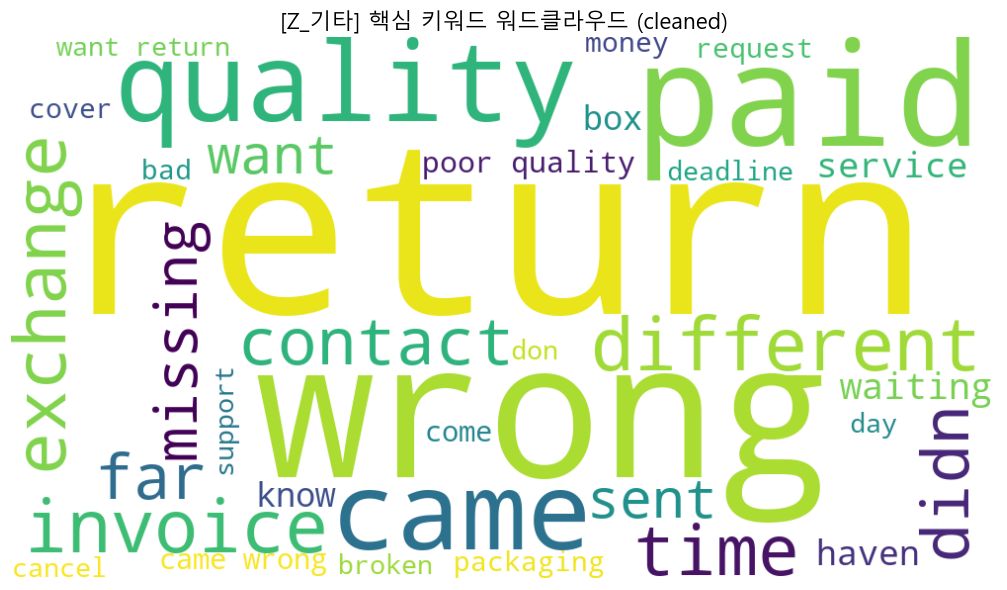

In [54]:

# ----------------------------
# 0) 기본/도메인 stopwords
# ----------------------------
english_stopwords = set(text.ENGLISH_STOP_WORDS)

domain_stopwords = {
    "product","products","item","items","order","orders",
    "buy","bought","purchase","purchased","store","seller","customer",
    "comment","comments","opinion","review","reviews",
    "good","great","excellent","ok","nice","recommend","recommended",
    "get","got","getting","say","said",
    "receive","received","receiving",
}

# ----------------------------
# 1) Z_기타에서 과하게 뜨는 공통 단어(배송/사이트/일반동사) 추가 제거
#    -> 여기 계속 추가하면서 다듬으면 워드클라우드 퀄이 확 좋아짐
# ----------------------------
z_noise_stopwords = {
    "delivery","delivered","deliver","shipping","ship","shipped",
    "arrive","arrived","arrival","late","delay","days","date",
    "site","website","app","status","tracking","track",
    "did","does","done","have","has","had","like",
    "received","receive","product", "item", "order",
}

STOPWORDS_Z = english_stopwords | domain_stopwords | z_noise_stopwords


# ----------------------------
# 2) 전처리 함수
# ----------------------------
def _clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)      # url 제거
    s = re.sub(r"[^a-z\s]", " ", s)             # 알파벳만
    s = re.sub(r"\s+", " ", s).strip()
    return s


# ----------------------------
# 3) 핵심 키워드(사용자가 직접 정의)
#    - "Z_기타"에 진짜 담고 싶은 이슈(소통/환불/응대/가품/파손/누락/오배송 등)
# ----------------------------
CORE_KEYWORDS = {
    # 고객응대/소통
    "support","service","contact","response","respond","reply","communication","rude",
    # 환불/반품/교환/취소
    "refund","return","exchange","cancel","cancellation","chargeback",
    # 품질/불량/파손/가품
    "broken","defective","faulty","damaged","damage","fake","counterfeit","quality",
    # 누락/오배송/구성품
    "missing","incomplete","wrong","different","mismatch","part",
    # 포장/구성
    "package","packaging","box","seal",
    # 결제/청구
    "payment","paid","charged","invoice",
}

# ----------------------------
# 4) Z_기타 워드클라우드 생성
#    mode="blacklist": stopwords로 잡음 제거 후 전체 키워드 기반
#    mode="whitelist": CORE_KEYWORDS(핵심 키워드)만 남겨서 생성
#    mode="boost": 전체 키워드 기반 + CORE_KEYWORDS에 가중치(부스팅) 부여
# ----------------------------
def make_z_wordcloud_from_text(
    neg_df: pd.DataFrame,
    text_col: str = "review_comment_translated",
    topic_group_col: str = "topic_group",
    z_group_value: str = "Z_기타",
    max_words: int = 120,
    ngram_range=(1,2),
    mode: str = "blacklist",   # "blacklist" | "whitelist" | "boost"
    core_keywords: set = None,
    boost_weight: float = 2.5, # boost 모드에서 core 키워드 가중치
):
    if core_keywords is None:
        core_keywords = set()

    z = neg_df[neg_df[topic_group_col] == z_group_value].copy()
    z = z[z[text_col].notna()]
    if len(z) == 0:
        print("[Z_기타] 텍스트 없음")
        return

    docs = z[text_col].map(_clean_text).tolist()

    # CountVectorizer로 단어/구(ngram) 빈도 집계
    vec = CountVectorizer(stop_words=list(STOPWORDS_Z), ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(docs)
    terms = np.array(vec.get_feature_names_out())
    freqs = np.asarray(X.sum(axis=0)).ravel()

    freq_dict = dict(zip(terms, freqs))
    if not freq_dict:
        print("[Z_기타] 단어 없음(필터 너무 강함) -> stopwords/min_df 완화 필요")
        return

    # ---------- 모드별 처리 ----------
    if mode == "whitelist":
        # 핵심 키워드(또는 핵심 키워드 포함 구)만 남김
        filtered = {}
        for t, f in freq_dict.items():
            # 단어 자체가 core 이거나, bigram 안에 core가 들어있으면 포함
            if (t in core_keywords) or any(tok in core_keywords for tok in t.split()):
                filtered[t] = f
        freq_dict = filtered

    elif mode == "boost":
        # 전체 유지 + core 포함 시 가중치 부여
        boosted = {}
        for t, f in freq_dict.items():
            if (t in core_keywords) or any(tok in core_keywords for tok in t.split()):
                boosted[t] = f * boost_weight
            else:
                boosted[t] = f
        freq_dict = boosted

    # mode == "blacklist": 그대로 진행

    if not freq_dict:
        print("[Z_기타] (whitelist/boost 결과) 단어 없음 -> CORE_KEYWORDS 확장 필요")
        return

    wc = WordCloud(
        width=1000,
        height=550,
        background_color="white",
        max_words=35,
        prefer_horizontal=0.9,
        collocations=False,
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    title = f"[Z_기타] 핵심 키워드 워드클라우드 (cleaned)"
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# ----------------------------
# 실행 예시
# ----------------------------

# 1) 추천: 배송/사이트 잡음 제거 중심(전체 기반)
#make_z_wordcloud_from_text(neg_df, mode="blacklist", core_keywords=CORE_KEYWORDS)

# 2) 더 빡세게: 내가 지정한 핵심 키워드만 보여주기
#make_z_wordcloud_from_text(neg_df, mode="whitelist", core_keywords=CORE_KEYWORDS)

# 3) 타협안: 전체는 보여주되, 핵심 키워드만 더 크게(가중치 부스팅)
make_z_wordcloud_from_text(neg_df, mode="boost", core_keywords=CORE_KEYWORDS, boost_weight=3.0)


In [55]:
neg_df

,review_id,review_comment_translated,review_score,bert_star,hybrid_score,final_label,topic_id,topic_group
8,67b1ab8f3ec19d5a90f153f21757d3a1,In the description of the product when I went ...,1.0,1,1.0,negative,-1,Z_기타
17,00800678dcf28b0ea0caef2147b6945d,I change my opinion as soon as I receive the p...,1.0,1,1.0,negative,35,Z_기타
37,28e20f3ef22e8795ea14e65f54e087a3,Delivery too long. I haven't received the prod...,1.0,2,1.2,negative,2,D_배송지연·기한초과
48,51ebb8fede4fbe6126f9f85ebdd23166,Promised delivery 24/05/17. Day 26/05/17 had n...,1.0,1,1.0,negative,2,D_배송지연·기한초과
53,048baba3f11436d12b06dab572aafc21,The product arrived and spoiled alone,1.0,1,1.0,negative,5,C_품질·파손·불량·가품
...,...,...,...,...,...,...,...,...
112568,94665539f5507a993b0ff44a7d13dd98,It's been a month since I made the purchase an...,1.0,1,1.0,negative,30,D_배송지연·기한초과
112602,03a047ebc544e597b4e65d8808b586dd,For now I am waiting for the product exchange,1.0,4,1.6,negative,10,D_배송지연·기한초과
112605,48031eee5cc3b788c2aa56d863e2bc3e,The chair has one leg smaller than the others.,1.0,3,1.4,negative,33,C_품질·파손·불량·가품
112610,35c38f254835f157b51a1770b91cb205,"Product, arrived correctly, but there was too ...",1.0,3,1.4,negative,36,D_배송지연·기한초과


In [ ]:
# 저장
# neg_df.to_csv("neg_df_topic_final.csv", index=False, encoding="utf-8-sig")

## ✅ 대시보드용 파일 2, 3
- `seller_review_topic_811.csv` 생성
- `wc_keyword_table.csv` 생성


[모집단 확인]
 - 리뷰 20건 이상 셀러 수(모집단): 811
⏳ 오염 방지 임계값 계산 중...
✅ MA 계산 완료.

[리스크 셀러 확인]
 - 최근 위험 감지 셀러 수(MA unpolluted): 68

[seller_summary 확인]
 - sellers: 811
 - MA risk sellers: 68

[seller_review_topic_811 확인]
 - unique sellers: 811
 - rows: 87113

[keyword_table 확인]
 - 키워드 있는 seller 수: 770
 - MA 리스크 seller 수(키워드 테이블 내): 68
 - 행 수: 16155

[워드클라우드 샘플 sellers]: ['054694fa03fe82cec4b7551487331d74', '05f51e13da97139648b8125c31e5f51b', '17306570e772e7718c92a562d33f5f1d']


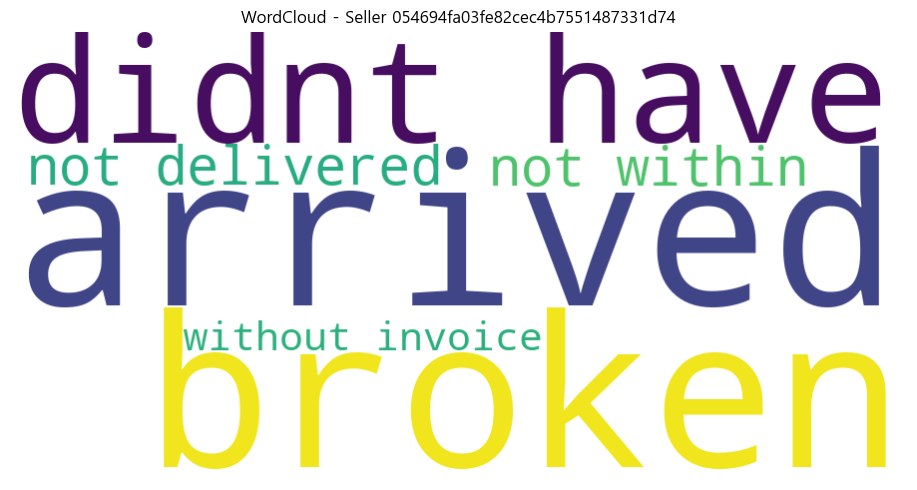

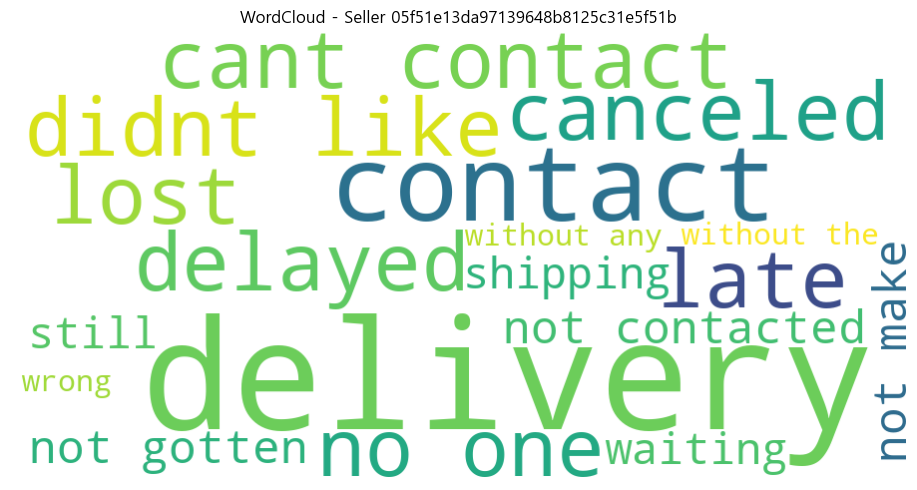

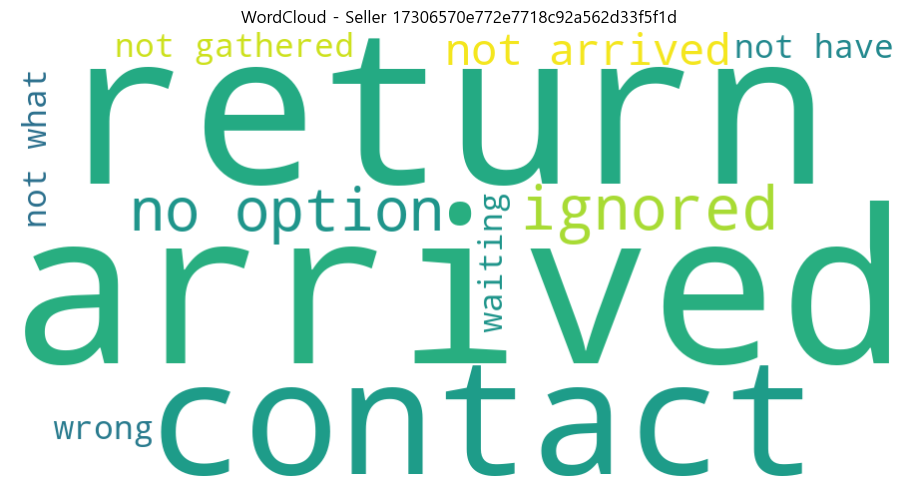

In [ ]:
# =========================================================
# 1) MA(오염방지) 리스크 계산 (모집단: 리뷰 20건 이상 = 811명)
# =========================================================
# df = pd.read_csv("merged_df_segment_Final.csv")
# neg_df = pd.read_csv("neg_df_topic_final.csv")

df_analysis = df.copy()
df_analysis["seller_id"] = df_analysis["seller_id"].astype(str)

df_analysis["review_score"] = pd.to_numeric(df_analysis["review_score"], errors="coerce")
df_analysis["is_negative"] = (df_analysis["review_score"] <= 2).astype(int)

# 리뷰 단위 중복 제거
df_analysis = df_analysis.drop_duplicates(subset=["seller_id", "review_id"])

sort_col = "order_purchase_timestamp"
df_analysis[sort_col] = pd.to_datetime(df_analysis[sort_col], errors="coerce")
df_analysis = df_analysis.dropna(subset=[sort_col]).sort_values(["seller_id", sort_col]).copy()

MIN_TOTAL_REVIEWS = 20
seller_counts = df_analysis.groupby("seller_id")["review_id"].nunique()
qualified_sellers = seller_counts[seller_counts >= MIN_TOTAL_REVIEWS].index.astype(str)
df_analysis = df_analysis[df_analysis["seller_id"].isin(qualified_sellers)].copy()

print("\n[모집단 확인]")
print(" - 리뷰 20건 이상 셀러 수(모집단):", df_analysis["seller_id"].nunique())  # 811

# MA 파라미터
WINDOW_SIZE = 10
CHECK_RANGE = 10
SIGMA_MULTIPLIER = 1.0
MIN_TOLERANCE = 0.30
MAX_CAP = 0.50

df_analysis["current_ma"] = (
    df_analysis.groupby("seller_id")["is_negative"]
    .transform(lambda x: x.rolling(window=WINDOW_SIZE, min_periods=5).mean())
)

def calculate_clean_threshold(group):
    thresholds, triggers = [], []
    n, sum_x, sum_sq = 0, 0.0, 0.0

    for _, row in group.iterrows():
        val = row["is_negative"]
        ma = row["current_ma"]

        if n < 2:
            mean, std = 0.0, 0.0
        else:
            mean = sum_x / n
            variance = (sum_sq / n) - (mean ** 2)
            std = np.sqrt(max(variance, 0.0))

        calc_th = mean + (SIGMA_MULTIPLIER * std)
        final_th = min(max(calc_th, MIN_TOLERANCE), MAX_CAP)

        is_risk = (ma >= final_th) if pd.notna(ma) else False

        thresholds.append(final_th)
        triggers.append(is_risk)

        # 오염 방지: 리스크면 통계 업데이트 제외
        if not is_risk:
            n += 1
            sum_x += val
            sum_sq += (val ** 2)

    return pd.DataFrame({"final_threshold": thresholds, "is_risk_triggered": triggers}, index=group.index)

print("⏳ 오염 방지 임계값 계산 중...")
results = df_analysis.groupby("seller_id", group_keys=False).apply(calculate_clean_threshold)
df_analysis["final_threshold"] = results["final_threshold"].values
df_analysis["is_risk_triggered"] = results["is_risk_triggered"].values
print("✅ MA 계산 완료.")

# 최근 CHECK_RANGE 구간에서 리스크 발생한 셀러(=68명)
recent_history = df_analysis.groupby("seller_id").tail(CHECK_RANGE)
risky_sellers_unpolluted_list = (
    recent_history.loc[recent_history["is_risk_triggered"] == True, "seller_id"]
    .astype(str).unique()
)
risky_set = set(map(str, risky_sellers_unpolluted_list))

print("\n[리스크 셀러 확인]")
print(" - 최근 위험 감지 셀러 수(MA unpolluted):", len(risky_sellers_unpolluted_list))

# =========================================================
# 2) seller_summary (내부용: 811명 + 리스크 플래그)
# =========================================================
seller_summary = pd.DataFrame({"seller_id": sorted(df_analysis["seller_id"].unique())})
seller_summary["seller_id"] = seller_summary["seller_id"].astype(str)
seller_summary["is_ma_risk_unpolluted"] = seller_summary["seller_id"].isin(risky_set).astype(int)

print("\n[seller_summary 확인]")
print(" - sellers:", seller_summary["seller_id"].nunique())  # 811
print(" - MA risk sellers:", int(seller_summary["is_ma_risk_unpolluted"].sum()))  # 68

# =========================================================
# 3) neg_df 준비(토픽/텍스트 매핑용)
# =========================================================
TEXT_COL = "review_comment_translated"
need_neg = ["review_id", TEXT_COL, "topic_group"]
miss2 = [c for c in need_neg if c not in neg_df.columns]
if miss2:
    raise ValueError(f"neg_df에 필수 컬럼 없음: {miss2}")

neg_df_map = neg_df[["review_id", TEXT_COL, "topic_group"]].copy()
neg_df_map["review_id"] = neg_df_map["review_id"].astype(str)
neg_df_map = neg_df_map.drop_duplicates(subset=["review_id"], keep="first")

# =========================================================
# 4) ✅ seller_review_topic_811.csv (리뷰 단위, 811명 유지)
#   - df_analysis 기반(=리뷰는 존재)
#   - topic_group / review_comment_translated는 있으면 채우고 없으면 NaN
#   - seller_total_reviews 제거
#   - 더미 없음
# =========================================================
need_cols = ["seller_id", "review_id", "is_negative"]
if "segment" in df_analysis.columns:
    need_cols.append("segment")

base_review = df_analysis[need_cols].copy()
base_review["seller_id"] = base_review["seller_id"].astype(str)
base_review["review_id"] = base_review["review_id"].astype(str)

if "segment" not in base_review.columns:
    base_review["segment"] = "Unknown"
else:
    base_review["segment"] = base_review["segment"].fillna("Unknown")

seller_review_topic_811 = base_review.merge(neg_df_map, on="review_id", how="left")

# 리스크 플래그 붙이기
seller_review_topic_811 = seller_review_topic_811.merge(
    seller_summary[["seller_id", "is_ma_risk_unpolluted"]],
    on="seller_id", how="left"
)
seller_review_topic_811["is_ma_risk_unpolluted"] = seller_review_topic_811["is_ma_risk_unpolluted"].fillna(0).astype(int)

print("\n[seller_review_topic_811 확인]")
print(" - unique sellers:", seller_review_topic_811["seller_id"].nunique())  # 811
print(" - rows:", len(seller_review_topic_811))

# =========================================================
# 5) wc_keyword_table.csv (키워드 단위)
#   - Unknown/NaN topic_group 제외
#   - neg_text 제거
#   - ✅ 감성 형용사/감성 구문 제거 (원인 중심)
#   - 입력은 "텍스트 있는 리뷰"만
# =========================================================
NEG_WORDS = {
    # 배송/미수령/추적
    "delay","delayed","late","waiting","wait","arrive","arrived","never","still",
    "missing","lost","stuck","tracking","undelivered","delivery","shipping",
    # 환불/반품/취소
    "refund","return","returned","cancel","canceled","chargeback",
    # 품질/파손
    "broken","damage","damaged","defect","defective","faulty","crack","scratched",
    # 오배송/누락
    "wrong","incorrect","different","incomplete","parts","piece","kit",
    # 사기/기타 강한 부정
    "fake","scam","fraud","terrible","worst","awful","horrible","useless",
    # 고객지원
    "support","contact","called","response","respond","ignored","ignore",
}

NEG_PHRASES = [
    "not received", "never arrived", "still waiting", "missing parts",
    "wrong item", "damaged item", "refund request", "return request",
]

NEGATOR_PATTERN = re.compile(
    r"\b(not|never|no|without|cannot|can't|cant|won't|wont|doesn't|doesnt|didn't|didnt|isn't|isnt|aren't|arent)\s+([a-z]{3,})\b"
)

CATEGORY_MAP = {
    "delivery": {
        "delay","delayed","late","waiting","wait","arrive","arrived","never","still",
        "missing","lost","stuck","tracking","undelivered","delivery","shipping"
    },
    "refund_return_cancel": {"refund","return","returned","cancel","canceled","chargeback"},
    "quality_damage": {"broken","damage","damaged","defect","defective","faulty","crack","scratched","useless"},
    "wrong_incomplete": {"wrong","incorrect","different","incomplete","parts","piece","kit"},
    "fake_scam": {"fake","scam","fraud","terrible","worst","awful","horrible"},
    "support_contact": {"support","contact","called","response","respond","ignored","ignore"},
}

def clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-z\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_token(w: str) -> str:
    w = str(w).lower().strip()
    w = re.sub(r"[^\w\s]", "", w)
    w = re.sub(r"\s+", " ", w)
    return w

def term_category(term: str, item_type: str) -> str:
    t = str(term).lower()

    # phrase
    if item_type == "phrase":
        if any(x in t for x in ["not received","never arrived","still waiting","tracking","undelivered","delivery","shipping","arrive"]):
            return "delivery"
        if any(x in t for x in ["refund","return","chargeback","cancel"]):
            return "refund_return_cancel"
        if any(x in t for x in ["damaged","broken","defect","faulty","crack","scratch"]):
            return "quality_damage"
        if any(x in t for x in ["wrong item","missing parts","incomplete"]):
            return "wrong_incomplete"
        return "other"

    # keyword
    if item_type == "keyword":
        for cat, vocab in CATEGORY_MAP.items():
            if t in vocab:
                return cat
        return "other"

    # neg_bigram (not X)
    if item_type == "neg_bigram":
        base = t.split(" ", 1)[1] if " " in t else t
        for cat, vocab in CATEGORY_MAP.items():
            if base in vocab:
                return cat
        return "other"

    return "other"

def extract_terms_per_review(text_clean: str):
    freq = {}

    # phrase count
    for ph in NEG_PHRASES:
        c = text_clean.count(ph)
        if c > 0:
            freq[(ph, "phrase")] = freq.get((ph, "phrase"), 0) + c

    # keyword count
    for tok in text_clean.split():
        tok = normalize_token(tok)
        if tok in NEG_WORDS:
            freq[(tok, "keyword")] = freq.get((tok, "keyword"), 0) + 1

    # negator bigram count
    for m in NEGATOR_PATTERN.finditer(text_clean):
        neg, w = m.group(1), m.group(2)
        neg = neg.replace("'", "")
        w = normalize_token(w)
        key = f"{neg} {w}"
        freq[(key, "neg_bigram")] = freq.get((key, "neg_bigram"), 0) + 1

    return freq

# 키워드 입력: 텍스트 있는 리뷰만
kw_base = seller_review_topic_811[
    seller_review_topic_811["review_comment_translated"].notna() &
    (seller_review_topic_811["review_comment_translated"].astype(str).str.len() > 0)
][["seller_id","segment","topic_group","review_id","review_comment_translated","is_negative"]].copy()

rows = []
for _, r in kw_base.iterrows():
    sid = str(r["seller_id"])
    seg = r["segment"]
    tg  = r["topic_group"]  # NaN 가능
    rid = str(r["review_id"])
    raw_text = str(r["review_comment_translated"])

    txt = clean_text(raw_text)
    if not txt:
        continue

    tf = extract_terms_per_review(txt)
    if not tf:
        continue

    for (term, item_type), f in tf.items():
        rows.append({
            "seller_id": sid,
            "segment": seg,
            "topic_group": tg,
            "review_id": rid,
            "term": term,
            "term_type": item_type,
            "category": term_category(term, item_type),
            "freq": int(f),
            "is_negative": int(r.get("is_negative", 1))
        })

keyword_table = pd.DataFrame(rows)

# Unknown/NaN topic_group 제외
if not keyword_table.empty:
    keyword_table = keyword_table.dropna(subset=["topic_group"]).copy()
    keyword_table = keyword_table[keyword_table["topic_group"].astype(str).str.lower() != "unknown"].copy()

if not keyword_table.empty:
    keyword_table = keyword_table.sort_values(
        ["seller_id","review_id","freq"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

# 리스크 플래그 붙이기
keyword_table = keyword_table.merge(
    seller_summary[["seller_id", "is_ma_risk_unpolluted"]],
    on="seller_id",
    how="left"
)
keyword_table["is_ma_risk_unpolluted"] = keyword_table["is_ma_risk_unpolluted"].fillna(0).astype(int)

print("\n[keyword_table 확인]")
if keyword_table.empty:
    print(" - keyword_table 비어있음")
else:
    print(" - 키워드 있는 seller 수:", keyword_table["seller_id"].nunique())
    print(" - MA 리스크 seller 수(키워드 테이블 내):",
          keyword_table.loc[keyword_table["is_ma_risk_unpolluted"]==1, "seller_id"].nunique())
    print(" - 행 수:", len(keyword_table))

# =========================================================
# 6) 워드클라우드 샘플 3명 출력(리스크 셀러 중 키워드 있는 사람 기준)
# =========================================================
def plot_wc_from_keyword_table(keyword_table_in, seller_id, max_words=120):
    d = keyword_table_in[keyword_table_in["seller_id"].astype(str) == str(seller_id)]
    if d.empty:
        print(f"{seller_id}: 키워드 없음(또는 Unknown 제외로 제거됨)")
        return

    freq = d.groupby("term")["freq"].sum().to_dict()
    if not freq:
        print(f"{seller_id}: term freq 없음")
        return

    wc = WordCloud(
        width=900, height=450,
        background_color="white",
        max_words=max_words,
        collocations=False
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - Seller {seller_id}")
    plt.tight_layout()
    plt.show()

sample_sellers = list(map(str, risky_sellers_unpolluted_list))[:3]
print("\n[워드클라우드 샘플 sellers]:", sample_sellers)

if not keyword_table.empty:
    for sid in sample_sellers:
        plot_wc_from_keyword_table(keyword_table, sid, max_words=120)

# =========================================================
# 7) CSV 2개만 저장
# =========================================================
#seller_review_topic_811.to_csv("seller_review_topic_811.csv", index=False, encoding="utf-8-sig")
#keyword_table.to_csv("wc_keyword_table.csv", index=False, encoding="utf-8-sig")
